# CIFAR-10 / ResNet18 — the two headline scans, and Fig 5

Sven (Gram backend, which is what makes a ResNet tractable) against ten baselines on
CIFAR-10 / ResNet18, on **both** objectives the campaign ran: label regression (one-hot
MSE) and cross-entropy. Then the reviewer figure R1 Q2 asks for: quality and cost against
the fraction of parameters updated per step.

What is in here, and where each number comes from:

| section | question | source |
|---|---|---|
| 1 | what did each method reach on 5 *fresh* seeds | `analysis/headline.py` on `{scan}_confirm` |
| 2 | how did it get there, per epoch and per second | `{scan}_confirm` curves; `{scan}_timing` for the time axis |
| 3 | did Sven fail to optimise, or fail to generalise | `losses.train_eval` beside `val` |
| 4 | is Sven's configuration on an edge of its grid | the scan's own Sven grid + `{scan}_diag` |
| 5 | what did it cost | `{scan}_timing` (standalone, one run per GPU) |
| 6 | Fig 5 | `rebuttal_fig5_cifar_paramfrac_scan` (3 seeds) + the profile study |
| 7 | the framing, computed from the tables above | — |

**BatchNorm policy.** Every optimizer on both scans ran with `bn_mode: batch` — batch
statistics during training, one running-statistics update per step, and evaluation with
the running statistics. It is the same for Sven and for every baseline, and it is stated
here because it is the single change that overturned the pre-campaign result: the legacy
"Sven ≈ Adam on CIFAR" came from evaluating Sven with *validation-batch* statistics.

**Provisional numbers.** The CIFAR-10 cross-entropy scan is still growing while decision 5's
`rtol` extension lands (`rtol` 0.03 / 0.1 / 0.3 at `k = 128`). The gate cell below prints a
banner whenever that is still true. Every cell here recomputes from
`bench/best_configs.json`, so re-running `tools/select_best.py` and then this notebook is
all that is needed — no cell names a configuration or repeats a number in prose.

**Fig 5 = `rebuttal_fig5_cifar_paramfrac_scan` (3 seeds).** The old 1-seed
`cifar10_resnet_paramFrac_scan_labelReg` was cut from the campaign (ANALYSIS_PLAN 1.2) and
is not in the fresh results root.

In [1]:
import sys, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, '.')
from pathlib import Path
from style import (load_results, set_style, DATASET_TITLES, metric_label, method_label,
                   method_color, seed_spread_label, band_legend, clipped_yerr)
from analysis_helpers import add_derived, method_order
import scan_analysis as sa
import headline as hl
import large_figs as lf
set_style()
pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)

PLOT_DIR = Path('plots_v2/cifar'); PLOT_DIR.mkdir(parents=True, exist_ok=True)
SCANS = {'cifar10_resnet_scan_labelRegression': DATASET_TITLES['cifar_labelreg'],
         'cifar10_resnet_ce_scan': DATASET_TITLES['cifar_ce']}
FIG5 = lf.FIG5_SCAN

def show(df, title=None):
    return hl.print_table(df, title)

## 0. Is the selection of record still the selection of what is on disk?

`headline.freshness_report()` compares `bench/best_configs.json`'s timestamp with the
records and the live claim files. A scan with a live claim, or with tuning records written
after the selection, is **PROVISIONAL**: the tables below are correct for the selection
they were built from, and that selection can still move.

In [2]:
print('selection of record:', hl.SELECTION_PATH)
print('generated at       :', hl.load_selection()['generated_at'])
print('selections checked (validation-only assertion):',
      hl.assert_no_test_selection(scans=list(SCANS)), '\n')

fresh = hl.freshness_report(scans=list(SCANS), kinds=('', 'confirm', 'timing', 'diag'))
show(fresh, 'the four passes of each CIFAR scan')

# The BatchNorm policy is an assertion, not a sentence: every record of both scans, every
# optimizer, carries the mode it ran under.
for scan, title in SCANS.items():
    df = add_derived(load_results(scan))
    modes = df['bn_mode'].value_counts(dropna=False).to_dict()
    print(f'{title}: bn_mode {modes} over {df["method"].nunique()} methods, '
          f'{df["model_seed"].nunique()} tuning seeds, {len(df)} runs')
    assert set(modes) == {'batch'}, f'{scan}: mixed BatchNorm policies {modes}'
PROVISIONAL = sorted(fresh.attrs['provisional_scans'])
if PROVISIONAL:
    live = int(fresh['n_claims_live'].sum())
    after = int(fresh.loc[fresh['selection_input'], 'n_after_selection'].sum())
    print('\n' + '!' * 78)
    print('PROVISIONAL: ' + ', '.join(SCANS.get(s, s) for s in PROVISIONAL))
    print(f'  {live} run(s) claimed by a live worker, {after} tuning record(s) newer than '
          f'the selection.')
    print('  Decision 5 (ANALYSIS_PLAN section 7) extends the CIFAR-CE rtol grid; when the '
          'jobs finish,')
    print('  re-run tools/select_best.py (BOTH groups, see A.impl.gpu-items.md) and then '
          'this notebook.')
    print('!' * 78)
else:
    print('\nNo scan is provisional: every table below is built from a settled selection.')

selection of record: /n/home11/sambt/iaifi/sv3/bench/best_configs.json
generated at       : 2026-09-20T03:58:14-0400
selections checked (validation-only assertion): 22 


### the four passes of each CIFAR scan
| scan | pass | selection_input | n_records | newest_record | n_after_selection | n_claims_live | provisional |
|---|---|---|---|---|---|---|---|
| cifar10_resnet_scan_labelRegression | scan | True | 600 | 2026-09-20 05:36:07 | 0 | 0 | False |
| cifar10_resnet_scan_labelRegression | confirm | False | 55 | 2026-09-20 09:54:20 | 55 | 0 | False |
| cifar10_resnet_scan_labelRegression | timing | False | 55 | 2026-09-20 11:41:36 | 55 | 0 | False |
| cifar10_resnet_scan_labelRegression | diag | False | 55 | 2026-09-20 10:01:28 | 55 | 0 | False |
| cifar10_resnet_ce_scan | scan | True | 775 | 2026-09-21 01:19:59 | 35 | 5 | True |
| cifar10_resnet_ce_scan | confirm | False | 55 | 2026-09-20 11:21:00 | 55 | 0 | False |
| cifar10_resnet_ce_scan | timing | False | 55 | 2026-09-20 11:37:29 |

CIFAR-10 (CE): bn_mode {'batch': 775} over 11 methods, 5 tuning seeds, 775 runs

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
PROVISIONAL: CIFAR-10 (CE)
  5 run(s) claimed by a live worker, 35 tuning record(s) newer than the selection.
  Decision 5 (ANALYSIS_PLAN section 7) extends the CIFAR-CE rtol grid; when the jobs finish,
  re-run tools/select_best.py (BOTH groups, see A.impl.gpu-items.md) and then this notebook.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


## 1. Headline: the selected configuration of every method on 5 fresh seeds

`headline.confirmation_table` is the one implementation of this table. Columns are the
confirmation seeds (base+100..104), with the tuning seeds the selection was made on beside
them — their difference is the selection optimism. `finished/attempted` is on every row;
`train (eval mode)` is the training loss of the trained model in eval mode on a fixed
subset, which section 3 uses.

In [3]:
CONF = {}
for scan, title in SCANS.items():
    CONF[scan] = hl.confirmation_table(scan)
    show(hl.confirmation_view(CONF[scan]), f'{title} — confirmation seeds (rank order)')
    n_meth = len(CONF[scan])
    sven = CONF[scan][CONF[scan].method == 'Sven'].iloc[0]
    rank = int((pd.to_numeric(CONF[scan]['val_conf'], errors='coerce')
                .rank(method='min')[CONF[scan].method.eq('Sven')]).iloc[0])
    print(f"\n  Sven on {title}: validation rank {rank} of {n_meth}; "
          f"config {sven['config']}")

Loaded 600 runs from ../experiment_results/_cache/cifar10_resnet_scan_labelRegression.slim.pkl (slim cache)
Loaded 55 runs from ../experiment_results/_cache/cifar10_resnet_scan_labelRegression_confirm.slim.pkl (slim cache)



### CIFAR-10 (label reg.) — confirmation seeds (rank order)
| method | config | val (confirm) | test (confirm) | test acc | train (eval mode) | finished/attempted | val (tuning) | tuning fin/att | gap (confirm-tune) | gap rel |
|---|---|---|---|---|---|---|---|---|---|---|
| MuonW | lr=0.01, weight_decay=0.1 | 0.3357 ± 0.005022 | 0.3437 ± 0.004633 | 0.763 ± 0.00393 | 0.2069 ± 0.00744 | 5/5 | 0.3456 ± 0.01007 | 5/5 | -0.009935 | -2.9% |
| SOAP | lr=0.01 | 0.3542 ± 0.01722 | 0.3625 ± 0.009357 | 0.779 ± 0.00602 | 0.03345 ± 0.001406 | 5/5 | 0.3524 ± 0.01079 | 5/5 | +0.001861 | +0.5% |
| Muon | lr=0.01 | 0.367 ± 0.0134 | 0.3808 ± 0.01499 | 0.773 ± 0.00395 | 0.03828 ± 0.007846 | 5/5 | 0.3649 ± 0.006447 | 5/5 | +0.002157 | +0.6% |
| AdamW | lr=0.01, weight_decay=0.01 | 0.4027 ± 0.007483 | 0.4015 ± 0.01123 | 0.728 ± 0.00916 | 0.1456 ± 0.02097 | 5/5 | 0.3952 ± 0.00817 | 5/5 | +0.007494 | +1.9% |
| Adam | lr=0.01 | 0.403 ± 0.01465 | 0.4005 ± 0.01111 | 0.734 ± 0.00754 | 0.1189 ± 0.01981 | 5/5 | 


### CIFAR-10 (CE) — confirmation seeds (rank order)
| method | config | val (confirm) | test (confirm) | test acc | train (eval mode) | finished/attempted | val (tuning) | tuning fin/att | gap (confirm-tune) | gap rel |
|---|---|---|---|---|---|---|---|---|---|---|
| MuonW | lr=0.01, weight_decay=0.1 | 0.7054 ± 0.02526 | 0.7073 ± 0.02504 | 0.768 ± 0.00826 | 0.3106 ± 0.02429 | 5/5 | 0.6888 ± 0.02447 | 5/5 | +0.01656 | +2.4% |
| Stochastic L-BFGS | lr=2, max_iter=2, history_size=5 | 1.063 ± 0.1266 | 1.09 ± 0.118 | 0.737 ± 0.0102 | 0.1519 ± 0.0531 | 5/5 | 1.014 ± 0.06558 | 5/5 | +0.04986 | +4.9% |
| SGD | lr=3 | 1.085 ± 0.07979 | 1.107 ± 0.07442 | 0.686 ± 0.0176 | 0.3555 ± 0.1697 | 5/5 | 1.118 ± 0.05159 | 5/5 | -0.03237 | -2.9% |
| AdamW | lr=0.01, weight_decay=0.01 | 1.101 ± 0.04974 | 1.108 ± 0.02582 | 0.735 ± 0.00287 | 0.09618 ± 0.01182 | 5/5 | 1.093 ± 0.06778 | 5/5 | +0.007572 | +0.7% |
| Muon | lr=0.01 | 1.137 ± 0.02377 | 1.18 ± 0.03377 | 0.779 ± 0.0021 | 0.03619 ± 0.003402 | 5/5 | 1

### Ranking, and paired differences against Sven

Validation is what everything was selected on; the test columns are **outcomes** of that
configuration. They can disagree, and on CIFAR they do. The paired tables difference
`Sven − other` within a model seed (same initialisation, same data order), so they remove
the seed-to-seed variation the unpaired spread is dominated by. `sven_better` counts the
pairs Sven won — direction-aware, so an accuracy row is not read under the loss
convention.

In [4]:
rank = hl.ranking_summary(scans=list(SCANS))
for value, label in (('rank_val', 'validation loss'), ('rank_test', 'test loss'),
                     ('rank_acc', 'test accuracy')):
    show(hl.rank_matrix(summary=rank, value=value, scans=list(SCANS)).reset_index(),
         f'rank per method — {label} (1 = best)')

for scan, title in SCANS.items():
    show(hl.paired_vs_sven(scan), f'{title} — paired Sven − other, validation loss')
    print(hl.paired_vs_sven(scan).attrs['sign'])
    for metric in ('final_test_loss', 'final_test_acc'):
        t = hl.paired_outcome_vs_sven(scan, metric=metric)
        show(t, f'{title} — paired Sven − other, {metric}')
        print(t.attrs['sign'])


### rank per method — validation loss (1 = best)
| title | Sven | Adam | AdamW | Muon | MuonW | Polyak SGD | RMSprop | SGD | SGD + momentum | SOAP | Stochastic L-BFGS |
|---|---|---|---|---|---|---|---|---|---|---|---|
| CIFAR-10 (label reg.) | 9 | 5 | 4 | 3 | 1 | 8 | 6 | 11 | 10 | 2 | 7 |
| CIFAR-10 (CE) | 9 | 7 | 4 | 5 | 1 | 11 | 8 | 3 | 10 | 6 | 2 |

### rank per method — test loss (1 = best)
| title | Sven | Adam | AdamW | Muon | MuonW | Polyak SGD | RMSprop | SGD | SGD + momentum | SOAP | Stochastic L-BFGS |
|---|---|---|---|---|---|---|---|---|---|---|---|
| CIFAR-10 (label reg.) | 9 | 4 | 5 | 3 | 1 | 8 | 6 | 11 | 10 | 2 | 7 |
| CIFAR-10 (CE) | 9 | 7 | 4 | 5 | 1 | 11 | 8 | 3 | 10 | 6 | 2 |

### rank per method — test accuracy (1 = best)
| title | Sven | Adam | AdamW | Muon | MuonW | Polyak SGD | RMSprop | SGD | SGD + momentum | SOAP | Stochastic L-BFGS |
|---|---|---|---|---|---|---|---|---|---|---|---|
| CIFAR-10 (label reg.) | 9 | 5 | 6 | 2 | 3 | 8 | 4 | 11 | 10 | 1 | 7 |
| CI

mean = Sven - other in final_val_loss (a loss): NEGATIVE means Sven is better; sven_better counts the pairs Sven won

### CIFAR-10 (label reg.) — paired Sven − other, final_test_loss
| method | display | reference | metric | n | mean | std | sem | ci_low | ci_high | half_width | level | n_unpaired | sven_better | significant |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| SGD | SGD | Sven | final_test_loss | 5 | -0.2397 | 0.00327 | 0.001463 | -0.2438 | -0.2357 | 0.004061 | 0.95 | 0 | 5 | True |
| SGDm | SGD + momentum | Sven | final_test_loss | 5 | -0.1876 | 0.01395 | 0.006238 | -0.2049 | -0.1703 | 0.01732 | 0.95 | 0 | 5 | True |
| PolyakSGD | Polyak SGD | Sven | final_test_loss | 5 | 0.02516 | 0.01947 | 0.008707 | 0.0009899 | 0.04934 | 0.02417 | 0.95 | 0 | 1 | True |
| LBFGS | Stochastic L-BFGS | Sven | final_test_loss | 5 | 0.04293 | 0.02374 | 0.01062 | 0.01346 | 0.07241 | 0.02947 | 0.95 | 0 | 0 | True |
| RMSprop | RMSprop | Sven | final_test_loss | 5 | 0.07731 | 0


### CIFAR-10 (CE) — paired Sven − other, validation loss
| method | display | reference | metric | n | mean | std | sem | ci_low | ci_high | half_width | level | mean_a | mean_b | n_unpaired | a_better | significant | sven_better |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| PolyakSGD | Polyak SGD | Sven | final_val_loss | 5 | -0.3425 | 0.03916 | 0.01751 | -0.3911 | -0.2939 | 0.04863 | 0.95 | 1.424 | 1.766 | 0 | 5 | True | 5 |
| SGDm | SGD + momentum | Sven | final_val_loss | 5 | -0.007263 | 0.4997 | 0.2235 | -0.6277 | 0.6132 | 0.6204 | 0.95 | 1.424 | 1.431 | 0 | 1 | False | 1 |
| RMSprop | RMSprop | Sven | final_val_loss | 5 | 0.1056 | 0.04697 | 0.021 | 0.04726 | 0.1639 | 0.05832 | 0.95 | 1.424 | 1.318 | 0 | 0 | True | 0 |
| Adam | Adam | Sven | final_val_loss | 5 | 0.1582 | 0.04984 | 0.02229 | 0.09627 | 0.22 | 0.06189 | 0.95 | 1.424 | 1.266 | 0 | 0 | True | 0 |
| SOAP | SOAP | Sven | final_val_loss | 5 | 0.2479 | 0.06552 | 0.0293 | 0.1665 | 0.3293 | 0


### CIFAR-10 (CE) — paired Sven − other, final_test_loss
| method | display | reference | metric | n | mean | std | sem | ci_low | ci_high | half_width | level | n_unpaired | sven_better | significant |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| PolyakSGD | Polyak SGD | Sven | final_test_loss | 5 | -0.3678 | 0.0217 | 0.009706 | -0.3948 | -0.3409 | 0.02695 | 0.95 | 0 | 5 | True |
| SGDm | SGD + momentum | Sven | final_test_loss | 5 | -0.04214 | 0.4839 | 0.2164 | -0.643 | 0.5587 | 0.6008 | 0.95 | 0 | 1 | False |
| RMSprop | RMSprop | Sven | final_test_loss | 5 | 0.04547 | 0.04711 | 0.02107 | -0.01303 | 0.104 | 0.0585 | 0.95 | 0 | 1 | False |
| Adam | Adam | Sven | final_test_loss | 5 | 0.108 | 0.05631 | 0.02518 | 0.03806 | 0.1779 | 0.06992 | 0.95 | 0 | 0 | True |
| SOAP | SOAP | Sven | final_test_loss | 5 | 0.1628 | 0.06169 | 0.02759 | 0.08619 | 0.2394 | 0.07659 | 0.95 | 0 | 0 | True |
| Muon | Muon | Sven | final_test_loss | 5 | 0.231 | 0.03101 | 0.01387 | 0.1925 |

## 2. Convergence: loss and accuracy, per epoch and per second

The **per-epoch** panels draw the same runs the tables above report — the selected
configuration in `{scan}_confirm`, through `large_figs.selected_runs_by_method` — so those
curves cannot drift away from their table. Validation / test curves start at epoch 0 (the
untrained model).

The **time-axis** panels are a different pass *and different seeds*, and both have to be
said. `{scan}_timing` is the only pass that had the GPU to itself, so quoting seconds from
the confirmation runs (which were sharded) would price the queue rather than the
optimizer; but the timing pass re-runs the *tuning* seeds (base+0..4), not the
confirmation seeds (base+100..104). The two therefore describe the same configuration on
different initialisations, and the seed set is printed on the figure
(`large_figs.seed_note`) so a curve there is not matched against the confirmation number
in the table. On CIFAR-CE that difference is Sven 1.40 (timing) against 1.42
(confirmation) — small, but it is not the same quantity.


Loaded 55 runs from ../experiment_results/_cache/cifar10_resnet_scan_labelRegression_timing.slim.pkl (slim cache)


Loaded 55 runs from ../experiment_results/_cache/cifar10_resnet_ce_scan_timing.slim.pkl (slim cache)


plots_v2/cifar/cifar10_resnet_scan_labelRegression_curves_vs_epoch.pdf


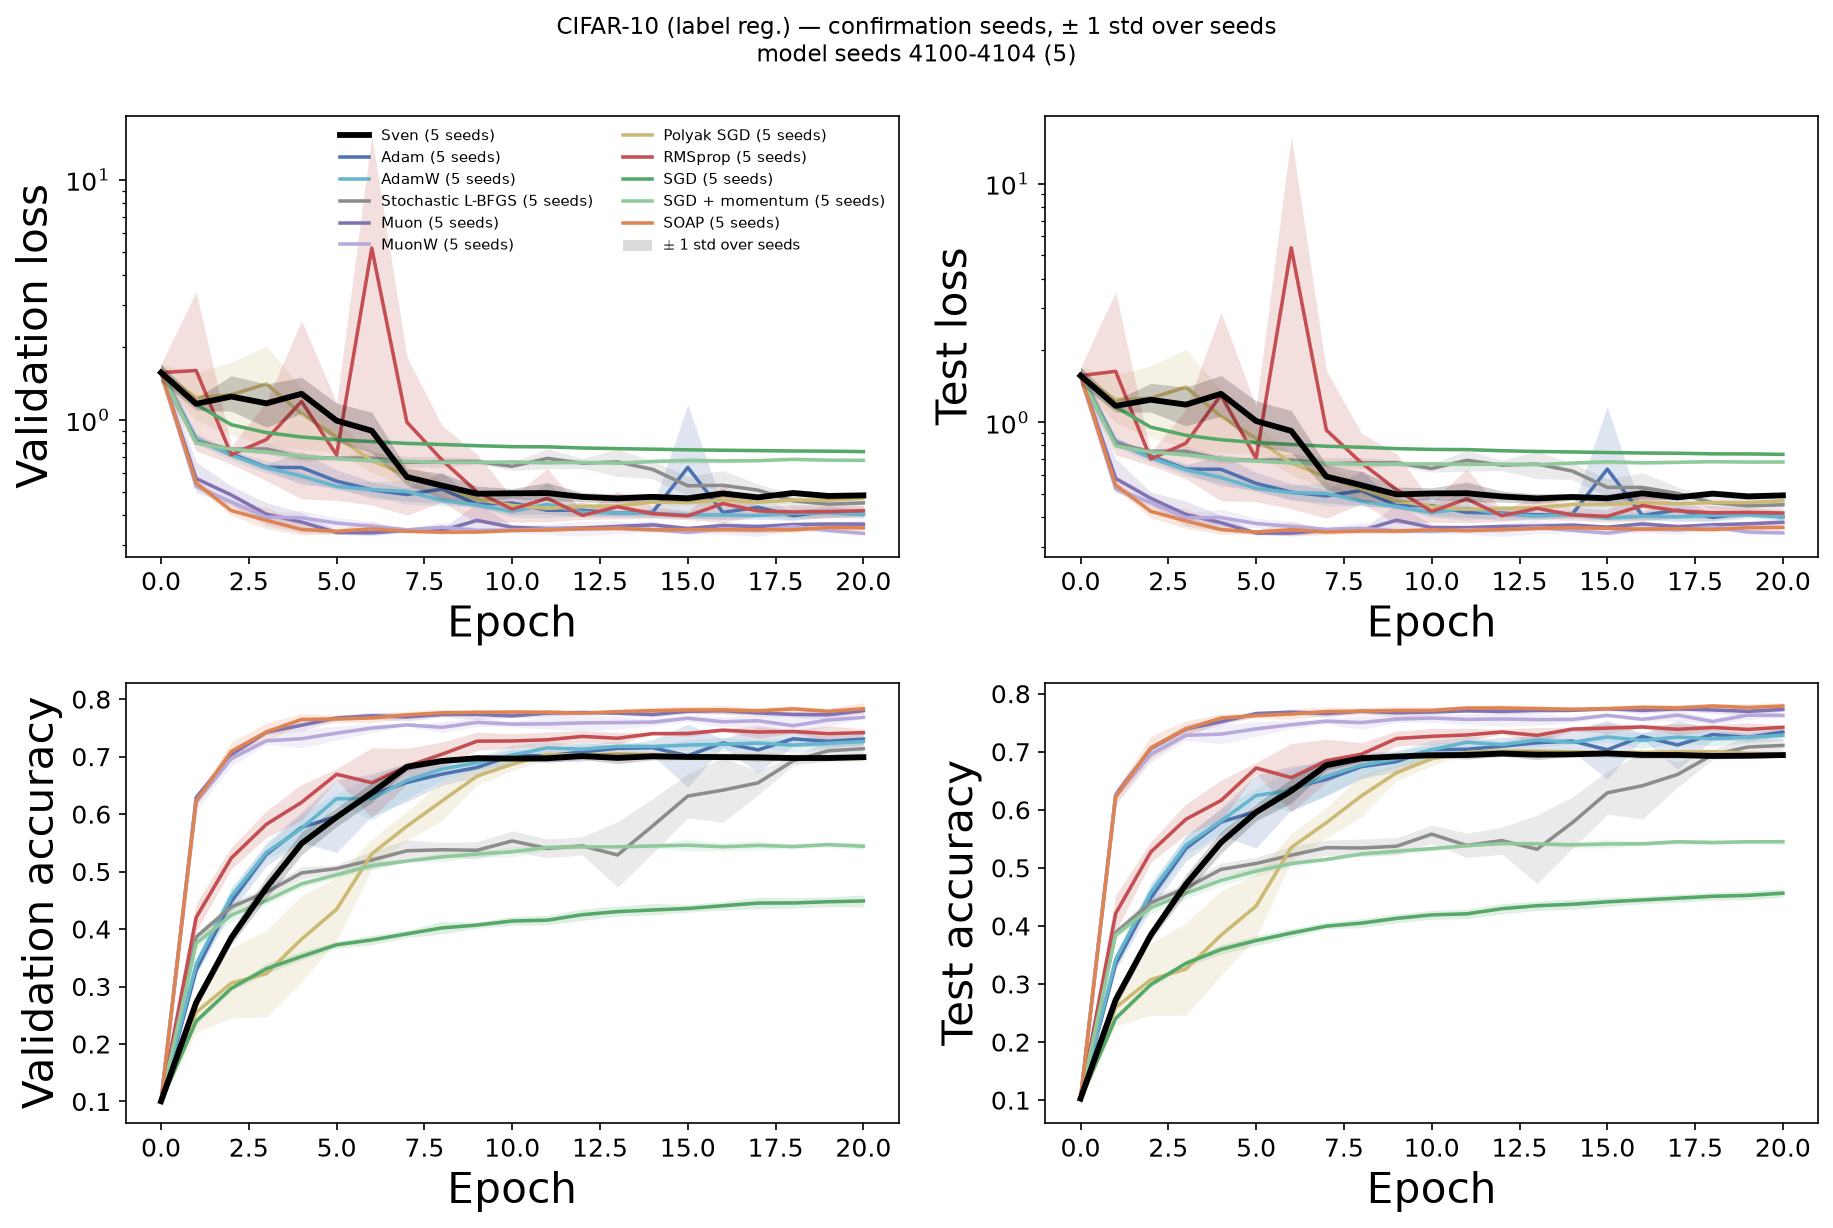

plots_v2/cifar/cifar10_resnet_ce_scan_curves_vs_epoch.pdf


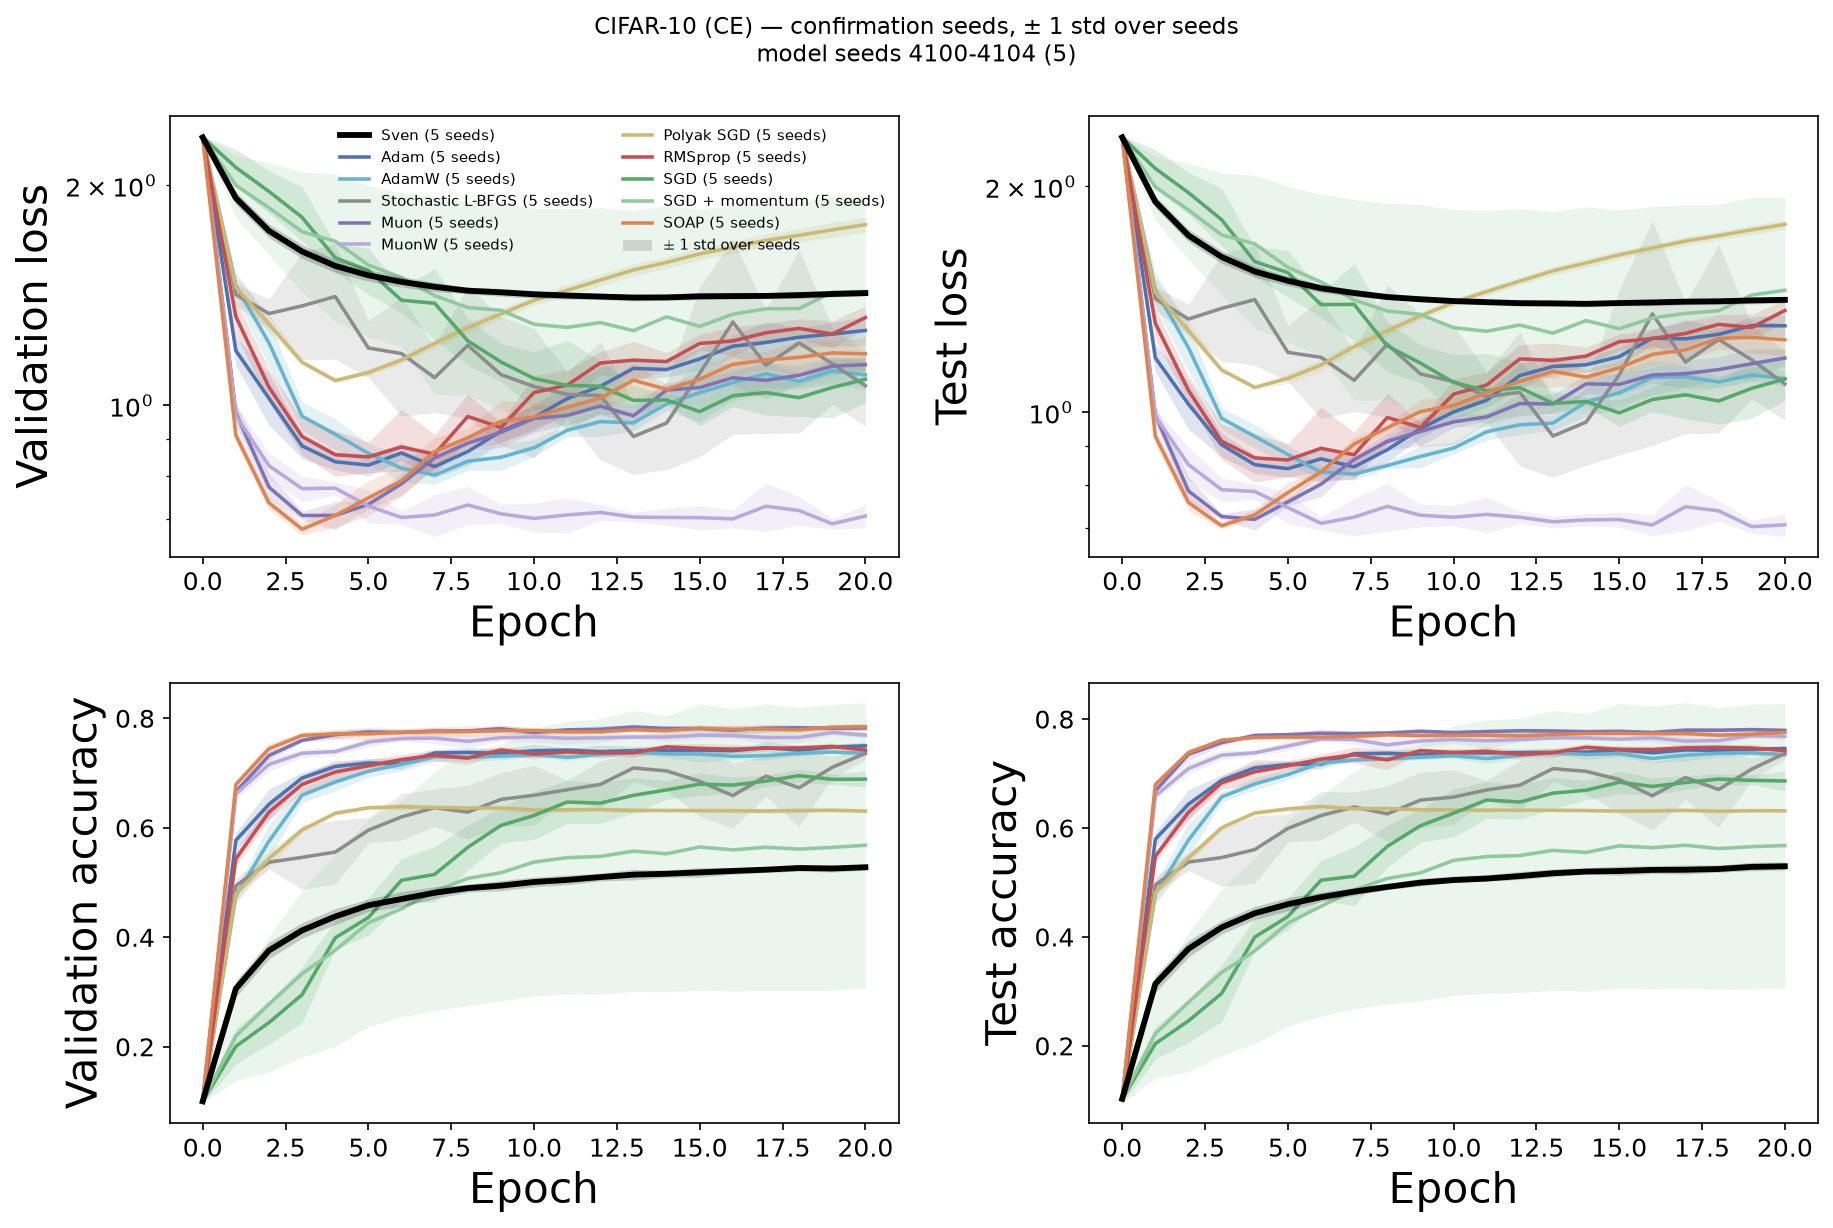

In [5]:
RUNS_CONF = {s: lf.selected_runs_by_method(s, 'confirm') for s in SCANS}
RUNS_TIME = {s: lf.selected_runs_by_method(s, 'timing') for s in SCANS}

for scan, title in SCANS.items():
    fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.4))
    for ax, key in zip(axes.ravel(), ('val', 'test', 'val_acc', 'test_acc')):
        lf.plot_curves(ax, RUNS_CONF[scan], key, versus='epoch')
    axes[0, 0].legend(fontsize=7, ncol=2)
    fig.suptitle(f'{title} — confirmation seeds, {seed_spread_label(plain=True)}\n'
                 f'{lf.seed_note(RUNS_CONF[scan])}', fontsize=11)
    fig.tight_layout()
    print(lf.savefig(fig, f'{scan}_curves_vs_epoch', PLOT_DIR)[0])
    plt.show()


plots_v2/cifar/cifar10_resnet_scan_labelRegression_curves_vs_time.pdf


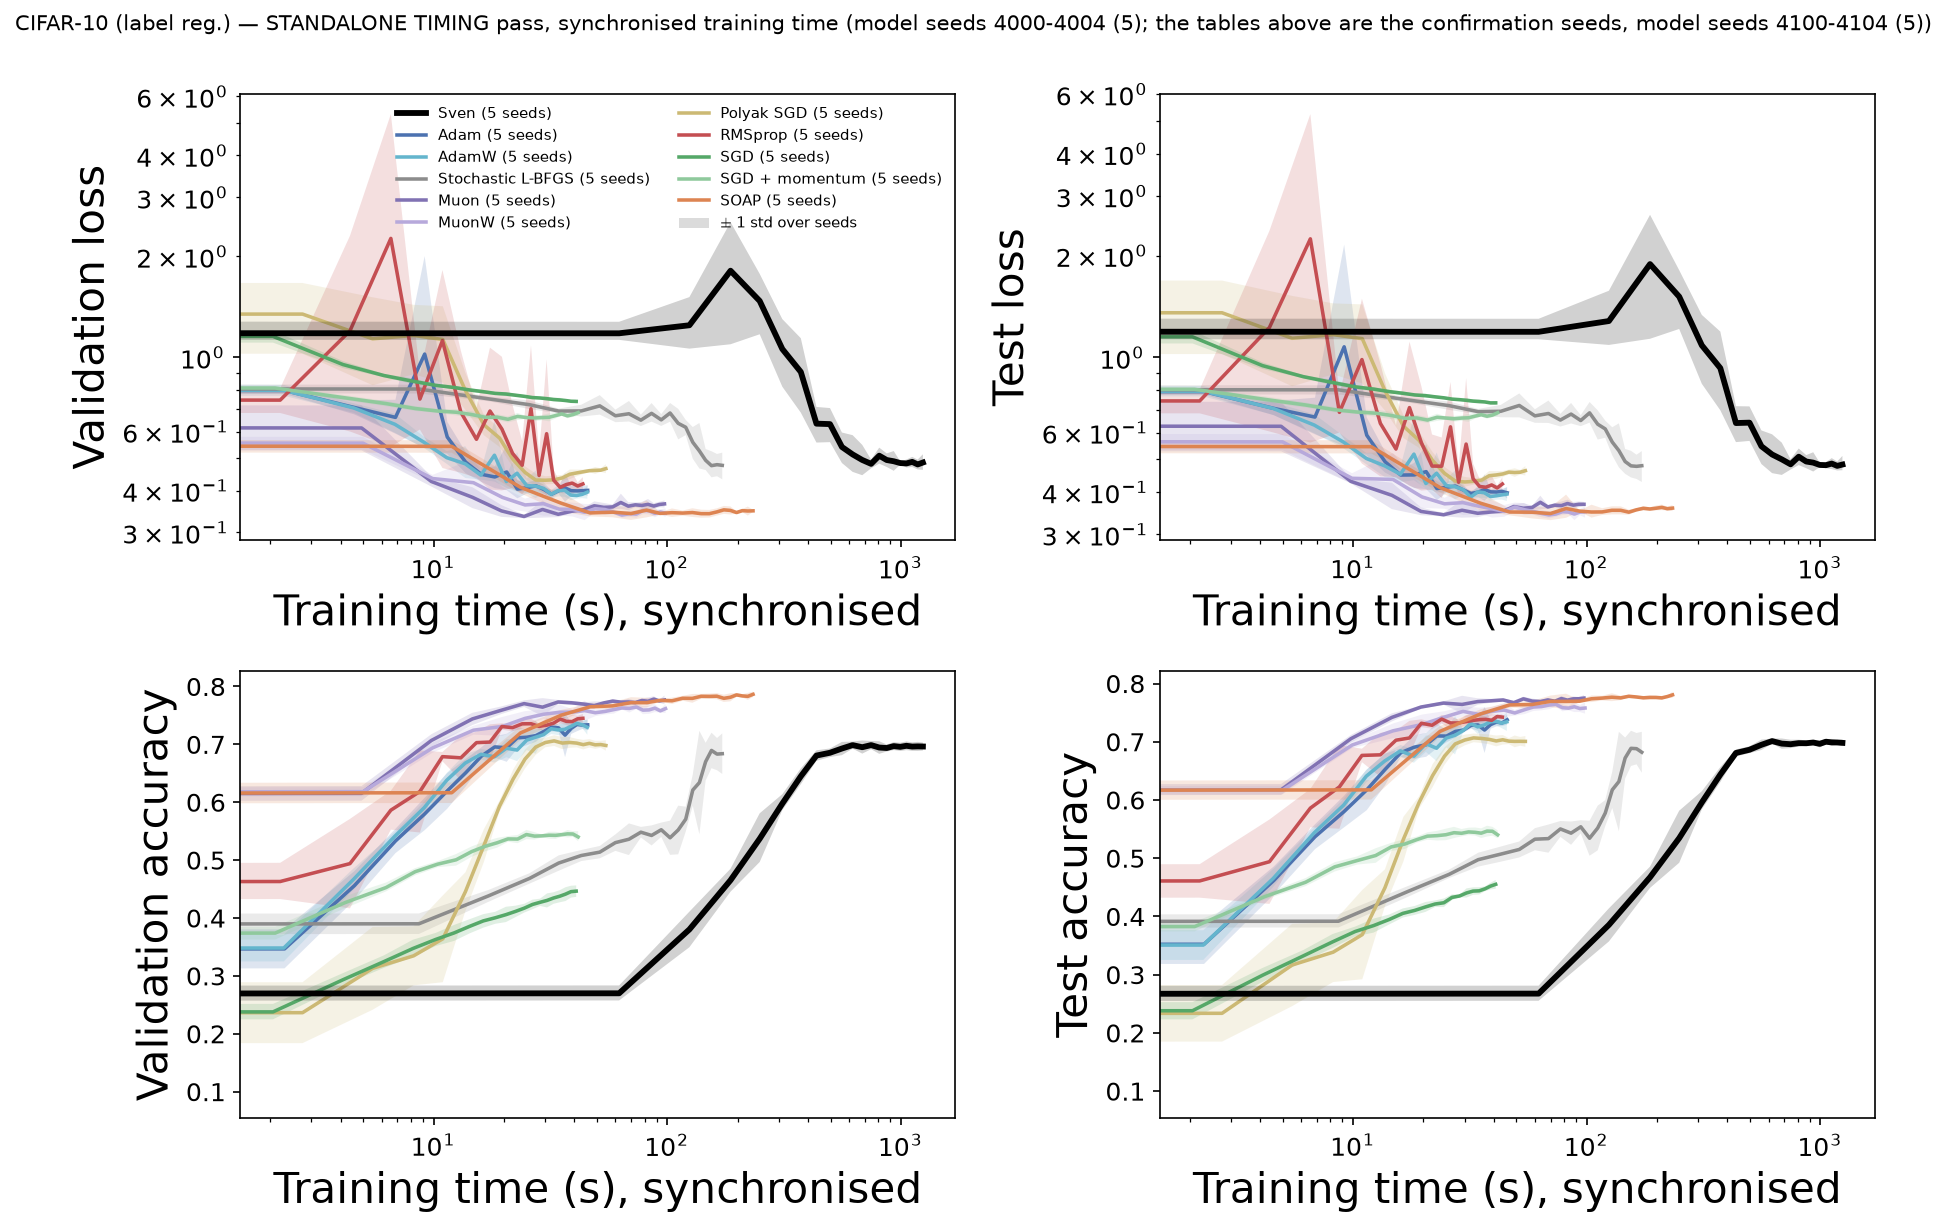

plots_v2/cifar/cifar10_resnet_ce_scan_curves_vs_time.pdf


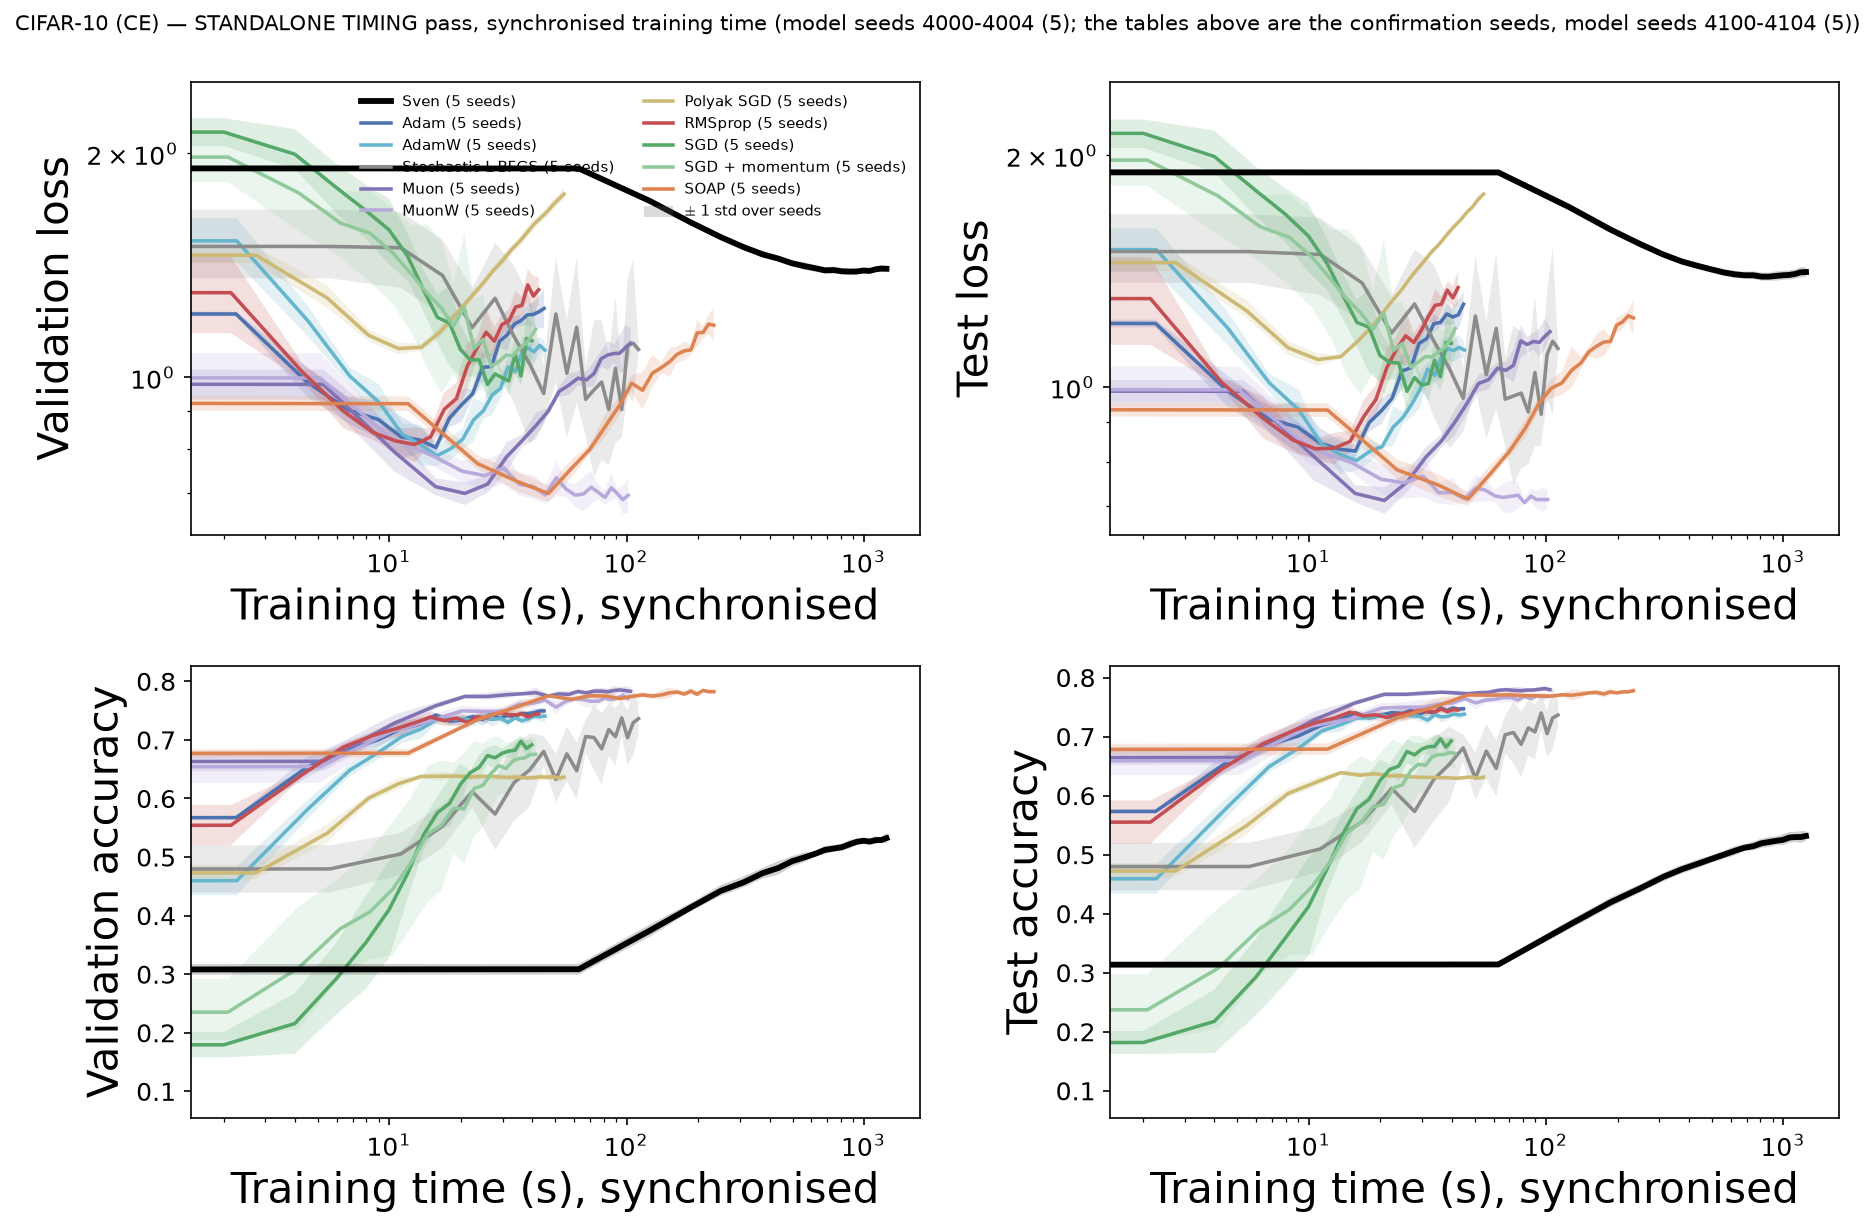

In [6]:
# Loss AND accuracy against synchronised training time -- the same four quantities as
# the per-epoch figure, so the two can be read against each other. These are the TIMING
# pass, i.e. the tuning seeds; `seed_note` puts that on the figure.
for scan, title in SCANS.items():
    fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.4))
    for ax, key in zip(axes.ravel(), ('val', 'test', 'val_acc', 'test_acc')):
        lf.plot_curves(ax, RUNS_TIME[scan], key, versus='time', time_key='train_times')
        ax.set_xscale('log')
    axes[0, 0].legend(fontsize=7, ncol=2)
    fig.suptitle(f'{title} — STANDALONE TIMING pass, synchronised training time '
                 f'({lf.seed_note(RUNS_TIME[scan])}; the tables above are the '
                 f'confirmation seeds, {lf.seed_note(RUNS_CONF[scan])})', fontsize=10)
    fig.tight_layout()
    print(lf.savefig(fig, f'{scan}_curves_vs_time', PLOT_DIR)[0])
    plt.show()


## 3. Did Sven fail to optimise, or fail to generalise?

`losses.train_eval` is the training loss of the trained model **in eval mode on a fixed
subset** — the same forward pass as validation, on data the model did fit. Put beside the
validation loss it separates two very different failures, and the two CIFAR objectives are
one of each:

* a LOW train_eval with a high val is a generalisation story;
* a HIGH train_eval says the optimiser never got there at all.

Everything in the table comes from the confirmation table of section 1.


### CIFAR-10 (label reg.) — optimisation vs generalisation
| method | config | train (eval mode) | val (confirm) | test (confirm) | val - train | val / train | finished/attempted | test acc |
|---|---|---|---|---|---|---|---|---|
| MuonW | lr=0.01, weight_decay=0.1 | 0.2069 ± 0.00744 | 0.3357 ± 0.005022 | 0.3437 ± 0.004633 | +0.1288 | 1.62 | 5/5 | 0.763 ± 0.00393 |
| SOAP | lr=0.01 | 0.03345 ± 0.001406 | 0.3542 ± 0.01722 | 0.3625 ± 0.009357 | +0.3208 | 10.59 | 5/5 | 0.779 ± 0.00602 |
| Muon | lr=0.01 | 0.03828 ± 0.007846 | 0.367 ± 0.0134 | 0.3808 ± 0.01499 | +0.3288 | 9.59 | 5/5 | 0.773 ± 0.00395 |
| AdamW | lr=0.01, weight_decay=0.01 | 0.1456 ± 0.02097 | 0.4027 ± 0.007483 | 0.4015 ± 0.01123 | +0.2571 | 2.77 | 5/5 | 0.728 ± 0.00916 |
| Adam | lr=0.01 | 0.1189 ± 0.01981 | 0.403 ± 0.01465 | 0.4005 ± 0.01111 | +0.2841 | 3.39 | 5/5 | 0.734 ± 0.00754 |
| RMSprop | lr=0.001 | 0.07515 ± 0.0145 | 0.4173 ± 0.01931 | 0.4165 ± 0.01258 | +0.3422 | 5.55 | 5/5 | 0.742 ± 0.00406 |
| Stochastic L-BFG

plots_v2/cifar/optimisation_vs_generalisation.pdf


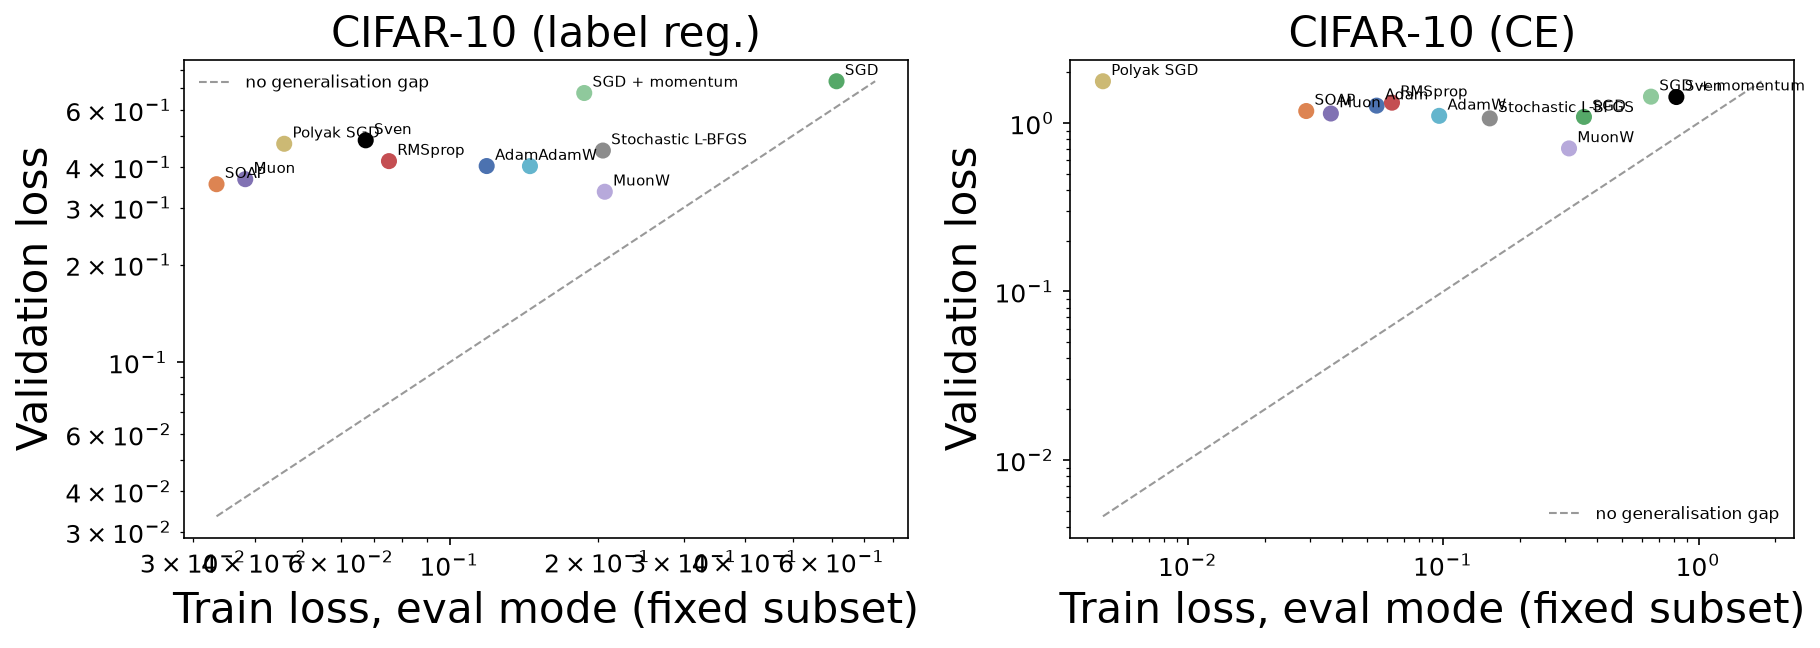

CIFAR-10 (label reg.): Sven train_eval 0.06737 vs the method median 0.1189  ->  Sven fits the training subset BETTER than the median method, and its validation loss is 0.4838 (gap +0.4164, x7.18 the train loss).
CIFAR-10 (CE): Sven train_eval 0.8186 vs the method median 0.09618  ->  Sven fits the training subset WORSE than the median method, and its validation loss is 1.424 (gap +0.6052, x1.74 the train loss).


In [7]:
GAPS = {}
for scan, title in SCANS.items():
    show(lf.optimisation_view(CONF[scan]), f'{title} — optimisation vs generalisation')
    GAPS[scan] = lf.generalisation_gaps(CONF[scan])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
for ax, (scan, title) in zip(axes, SCANS.items()):
    g = GAPS[scan].dropna(subset=['train_eval', 'val'])
    ax.scatter(g['train_eval'], g['val'], c=[method_color(m) for m in g['method']], s=45,
               zorder=3)
    for _, r in g.iterrows():
        ax.annotate(method_label(r['method']), (r['train_eval'], r['val']), fontsize=7,
                    xytext=(4, 3), textcoords='offset points')
    lo = float(np.nanmin([g['train_eval'].min(), g['val'].min()]))
    hi = float(np.nanmax([g['train_eval'].max(), g['val'].max()]))
    ax.plot([lo, hi], [lo, hi], color='0.6', lw=1, ls='--', zorder=1,
            label='no generalisation gap')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Train loss, eval mode (fixed subset)')
    ax.set_ylabel('Validation loss')
    ax.set_title(title); ax.legend(fontsize=8)
fig.tight_layout()
print(lf.savefig(fig, 'optimisation_vs_generalisation', PLOT_DIR)[0])
plt.show()

for scan, title in SCANS.items():
    g = GAPS[scan].set_index('method')
    s = g.loc['Sven']
    median_tr = float(np.nanmedian(g['train_eval']))
    print(f'{title}: Sven train_eval {s["train_eval"]:.4g} vs the method median '
          f'{median_tr:.4g}  ->  Sven fits the training subset '
          f'{"BETTER" if s["train_eval"] < median_tr else "WORSE"} than the median method, '
          f'and its validation loss is {s["val"]:.4g} '
          f'(gap {s["gap"]:+.4g}, x{s["val"] / s["train_eval"]:.2f} the train loss).')

### Accuracy on the same three splits

The label-regression scan is trained on one-hot MSE, so its accuracy is an argmax of a
regression output — still the number a reader compares across methods, which is why it is
reported for both objectives.

plots_v2/cifar/accuracy_train_val_test.pdf


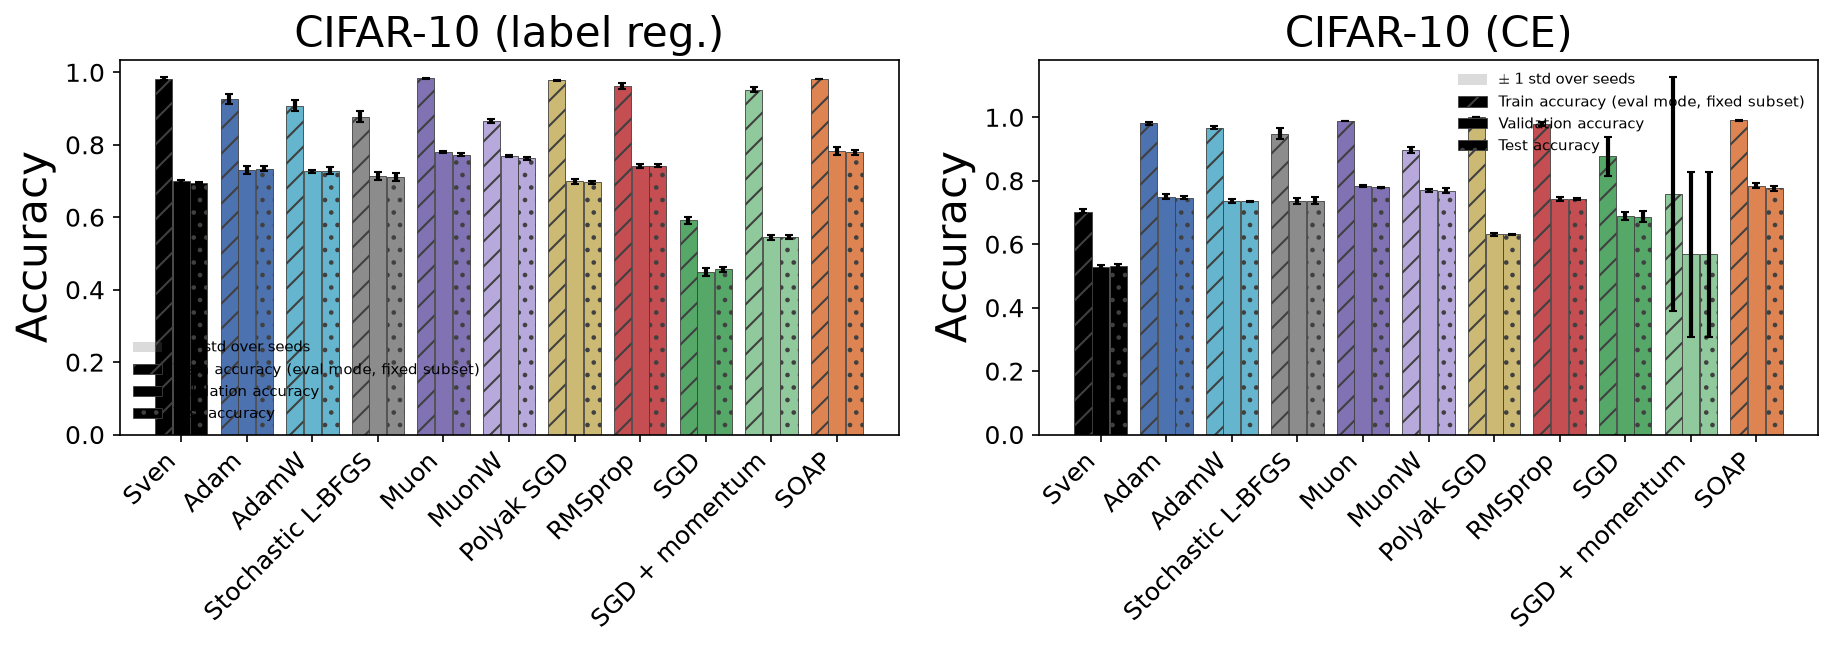

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
for ax, (scan, title) in zip(axes, SCANS.items()):
    methods = list(RUNS_CONF[scan])
    x = np.arange(len(methods))
    for off, key, hatch in ((-0.27, 'train_eval_acc', '//'), (0.0, 'val_acc', None),
                            (0.27, 'test_acc', '..')):
        vals, errs, lows = [], [], []
        for m in methods:
            mean, lower, upper, n = lf.curve_band(RUNS_CONF[scan][m], key)
            vals.append(np.nan if mean is None else mean[-1])
            errs.append(0.0 if mean is None else float(upper[-1] - mean[-1]))
            lows.append(np.nan if mean is None else lower[-1])
        v = np.asarray(vals, dtype=float)
        ax.bar(x + off, v, width=0.26, hatch=hatch, edgecolor='0.25', linewidth=0.4,
               color=[method_color(m) for m in methods],
               yerr=clipped_yerr(v, np.asarray(errs, float), np.asarray(lows, float)),
               capsize=2, label=lf.curve_label(key))
    ax.set_xticks(x); ax.set_xticklabels([method_label(m) for m in methods], rotation=45,
                                         ha='right')
    ax.set_ylabel('Accuracy'); ax.set_title(title)
    band_legend(ax); ax.legend(fontsize=7)
fig.tight_layout()
print(lf.savefig(fig, 'accuracy_train_val_test', PLOT_DIR)[0])
plt.show()

## 4. Sven's hyperparameter landscape

The grid the selection was made on, as the scan itself sees it
(`scan_analysis.Scan.configs`: eligible → fewest diverged → seed mean). The CIFAR-CE grid
is **ragged**: decision 5's extension adds `rtol` 0.03 / 0.1 / 0.3 at `k = 128` and three
of the five learning rates only. Three states are marked, and they are different states:

* a cell **nothing ran** is blank and marked `--`;
* a cell with **fewer runs than seeds** — because they have not landed, or because some
  diverged — carries its own `finished/attempted` under the number. While the extension
  lands, every one of its cells holds 3 or 4 of 5 seeds — and
  the best of them currently undercuts the red-ringed selection of record, which is
  exactly the comparison a reader takes off this figure, so a 3-seed mean must not be
  drawn like a 5-seed one;
* a cell that is **not eligible** (fewer than half its seeds produced a result) is dashed
  and marked `*`. It never entered the selection. On label regression that is a cell where
  Sven itself diverged.


In [9]:
GRID = {}
for scan, title in SCANS.items():
    g = lf.mark_selected(lf.sven_grid(scan), scan)
    GRID[scan] = g
    show(g.head(12), f'{title} — Sven grid, best 12 configurations (of {len(g)})')
    sel = g[g['selected']]
    edges = []
    if len(sel):
        s = sel.iloc[0]
        for col in ('k', 'lr', 'rtol'):
            vals = sorted(g[col].dropna().unique())
            if len(vals) > 1 and float(s[col]) in (vals[0], vals[-1]):
                edges.append(f"{col}={s[col]:g} ({'LOW' if float(s[col]) == vals[0] else 'HIGH'} edge)")
    print(f'  selected: ' + (', '.join(f'{c}={sel.iloc[0][c]:g}' for c in ('k', 'lr', 'rtol'))
                             if len(sel) else '(not on this grid)'))
    print(f'  on a grid edge: ' + (', '.join(edges) if edges else 'no'))
    bad = g[~g['eligible']]
    print(f'  not eligible (>= half the seeds missing or diverged): {len(bad)} of {len(g)}'
          + (f'  [still landing: {int((bad["n_missing"] > 0).sum())}, '
             f'mostly diverged: {int((bad["n_diverged"] > 0).sum())}]' if len(bad) else ''))
    part = g[(g['finished'] < g['attempted']) & g['eligible']]
    if len(part):
        msg = (f'  eligible but INCOMPLETE (drawn with their seed count): {len(part)} of '
               f'{len(g)}; best of them {part["val"].min():.4g}')
        if len(sel):
            msg += f' against the selected {sel.iloc[0]["val"]:.4g}'
        print(msg)
    # Divergences are counted over the runs that HAVE A RECORD: `attempted` comes from the
    # manifest, so while the extension lands it includes runs that never started, and
    # dividing by it would count those as clean (EXPERIMENTS.md section 7 quotes this row
    # on its on-grid records for the same reason).
    d = lf.grid_divergence_counts(g)
    print(f'  diverged Sven runs on this grid: {d["diverged"]} of {d["recorded"]} runs '
          f'RECORDED ({d["rate"]:.1%})'
          + (f'; {d["missing"]} of the {d["attempted"]} intended have not started yet'
             if d['missing'] else f' = all {d["attempted"]} intended'))
    if d['missing']:
        print(f'  the {d["missing"]} missing run(s) are the decision-5 rtol extension, which '
              f'is off the original manifest — which is also why the loader line above can '
              f'read "more records than intended".')


Loaded 600 runs from ../experiment_results/_cache/cifar10_resnet_scan_labelRegression.slim.pkl (slim cache)
cifar10_resnet_scan_labelRegression: 600 runs  |  B=128, 20 epochs, 5 seeds  |  Sven k=[64, 128] rtol=[0.0001, 0.001, 0.01]
  33 diverged run(s), excluded from seed means: {'SGDm': 15, 'SGD': 13, 'SVD': 5}
  manifest: 600 of 600 intended runs present, 0 with no record

### CIFAR-10 (label reg.) — Sven grid, best 12 configurations (of 18)
| k | lr | rtol | val | val_std | val_min | finished | attempted | n_diverged | n_failed | n_missing | eligible | selected |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 128 | 0.5 | 0.001 | 0.4803 | 0.01326 | 0.4581 | 5 | 5 | 0 | 0 | 0 | True | True |
| 128 | 0.5 | 0.0001 | 0.4861 | 0.01131 | 0.4699 | 5 | 5 | 0 | 0 | 0 | True | False |
| 64 | 0.5 | 0.001 | 0.5325 | 0.0189 | 0.5109 | 5 | 5 | 0 | 0 | 0 | True | False |
| 64 | 0.5 | 0.0001 | 0.5393 | 0.01458 | 0.5253 | 5 | 5 | 0 | 0 | 0 | True | False |
| 128 | 0.5 | 0.01 | 0.6838 | 0.156

cifar10_resnet_ce_scan: 775 runs  |  B=128, 20 epochs, 5 seeds  |  Sven k=[64, 128] rtol=[0.0001, 0.001, 0.01, 0.03, 0.1, 0.3]
  11 diverged run(s), excluded from seed means: {'RMSprop': 8, 'SOAP': 1, 'Muon': 1, 'SGDm': 1}
  manifest: 775 of 635 intended runs present, 10 with no record
    first missing: ['svd_bs128_k128_lr0.05_rtol0.03_svdtorch_mseed4004_lseed4000_gram_bnbatch', 'svd_bs128_k128_lr0.05_rtol0.1_svdtorch_mseed4004_lseed4000_gram_bnbatch', 'svd_bs128_k128_lr0.05_rtol0.3_svdtorch_mseed4004_lseed4000_gram_bnbatch']

### CIFAR-10 (CE) — Sven grid, best 12 configurations (of 39)
| k | lr | rtol | val | val_std | val_min | finished | attempted | n_diverged | n_failed | n_missing | eligible | selected |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 128 | 0.5 | 0.3 | 1.354 | 0.02433 | 1.326 | 3 | 5 | 0 | 0 | 2 | True | False |
| 128 | 0.1 | 0.1 | 1.365 | 0.01763 | 1.353 | 4 | 5 | 0 | 0 | 1 | True | False |
| 128 | 0.1 | 0.03 | 1.398 | 0.01817 | 1.385 | 4 | 5 | 0 | 0 | 

CIFAR-10 (label reg.): 2 cell(s) with fewer runs than seeds, annotated with their finished/attempted; 1 not eligible


plots_v2/cifar/cifar10_resnet_scan_labelRegression_sven_landscape.pdf


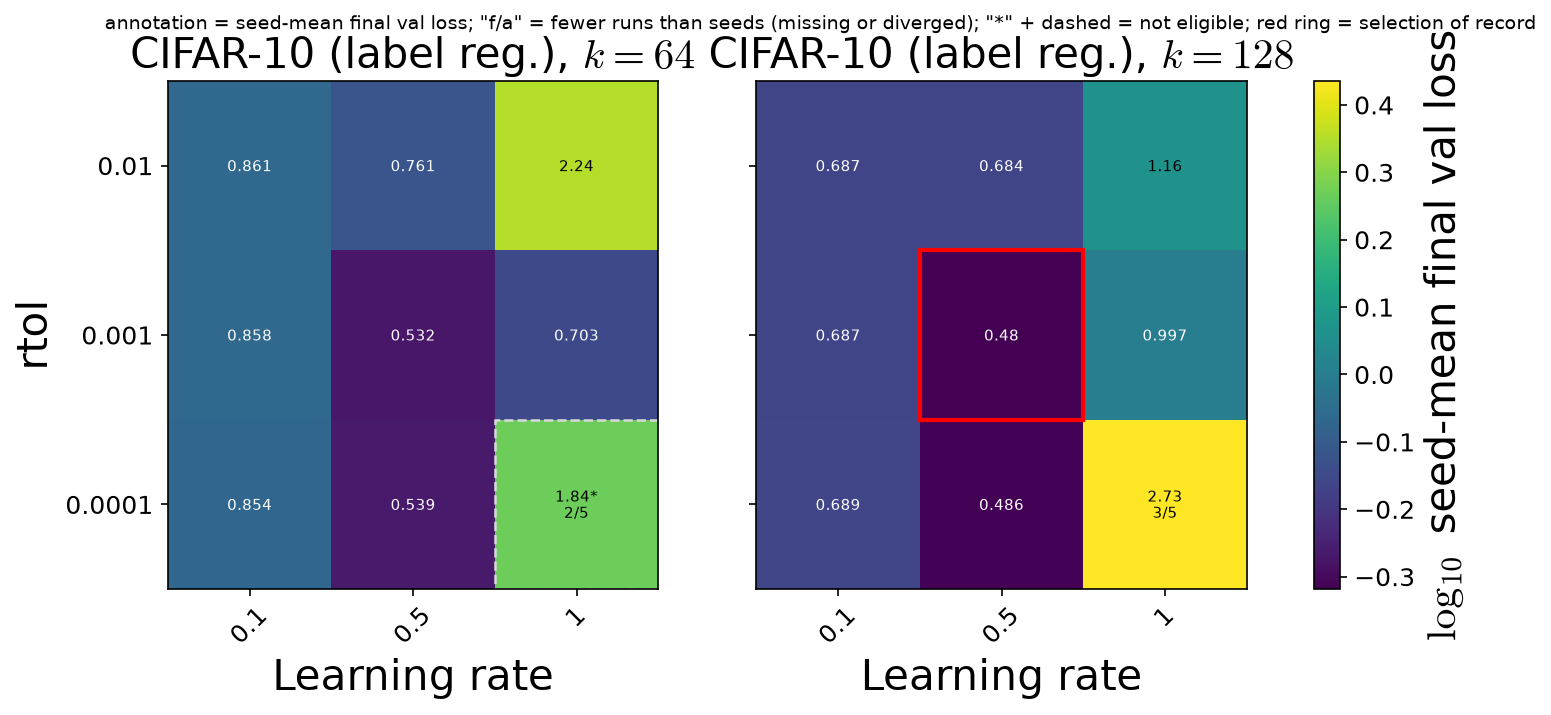

Loaded 600 runs from ../experiment_results/_cache/cifar10_resnet_scan_labelRegression.slim.pkl (slim cache)
cifar10_resnet_scan_labelRegression: 600 runs  |  B=128, 20 epochs, 5 seeds  |  Sven k=[64, 128] rtol=[0.0001, 0.001, 0.01]
  33 diverged run(s), excluded from seed means: {'SGDm': 15, 'SGD': 13, 'SVD': 5}
  manifest: 600 of 600 intended runs present, 0 with no record


plots_v2/cifar/cifar10_resnet_scan_labelRegression_sven_sensitivity.pdf


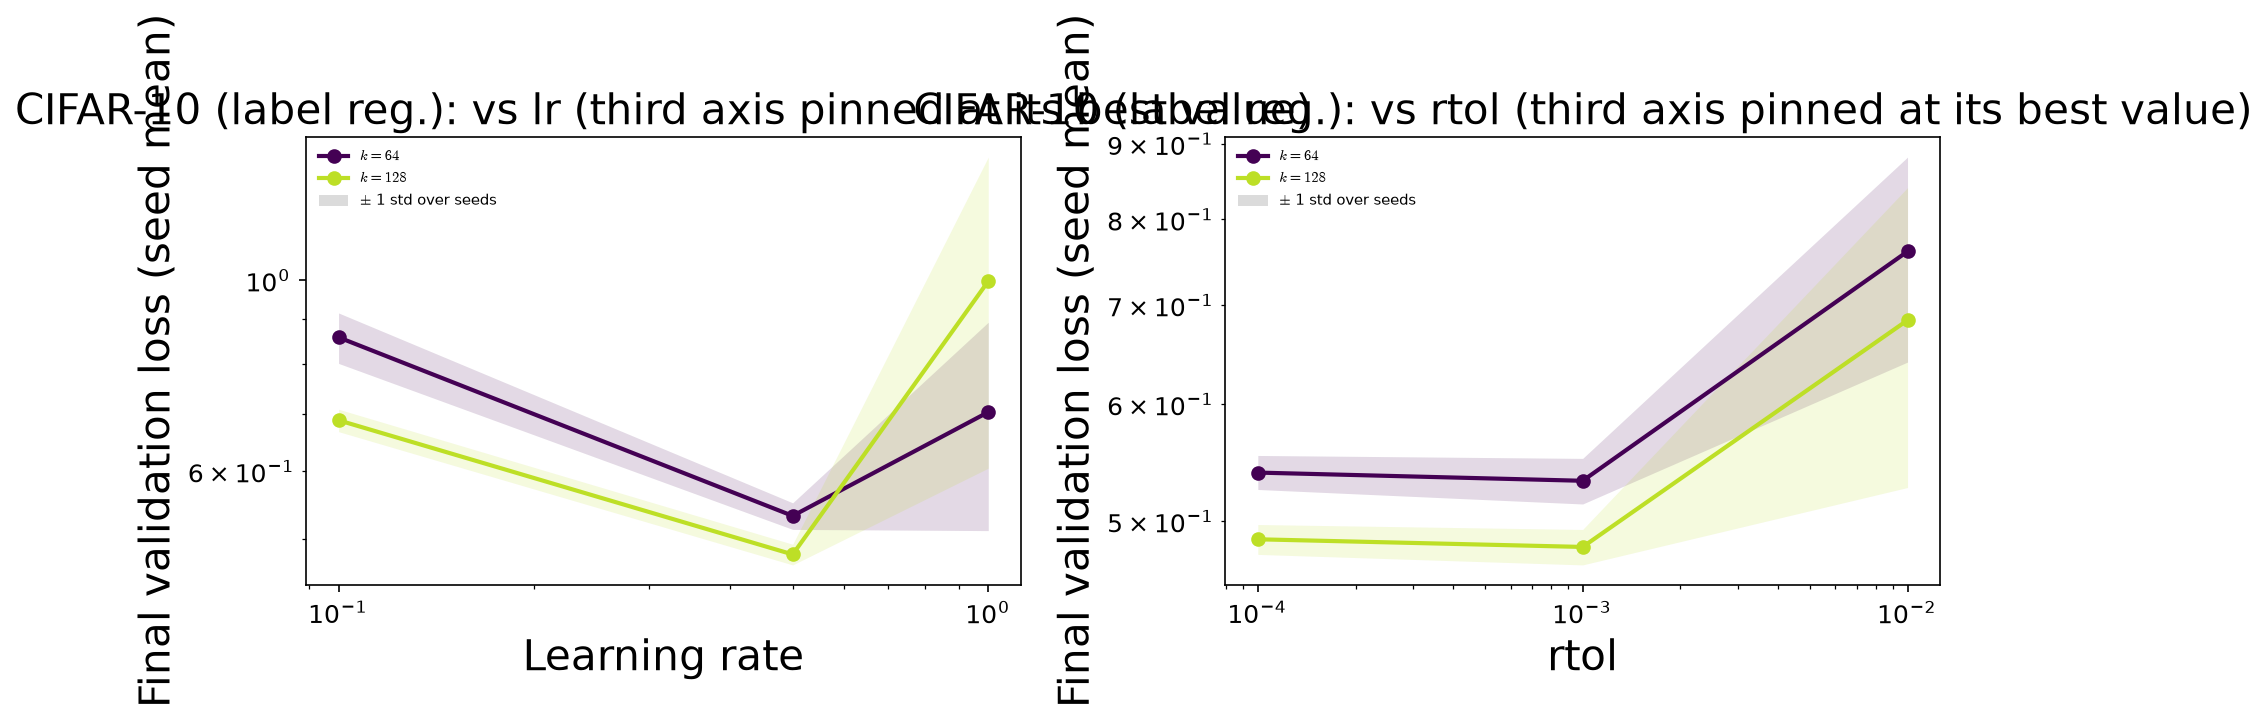

CIFAR-10 (CE): 9 cell(s) with fewer runs than seeds, annotated with their finished/attempted; 0 not eligible


plots_v2/cifar/cifar10_resnet_ce_scan_sven_landscape.pdf


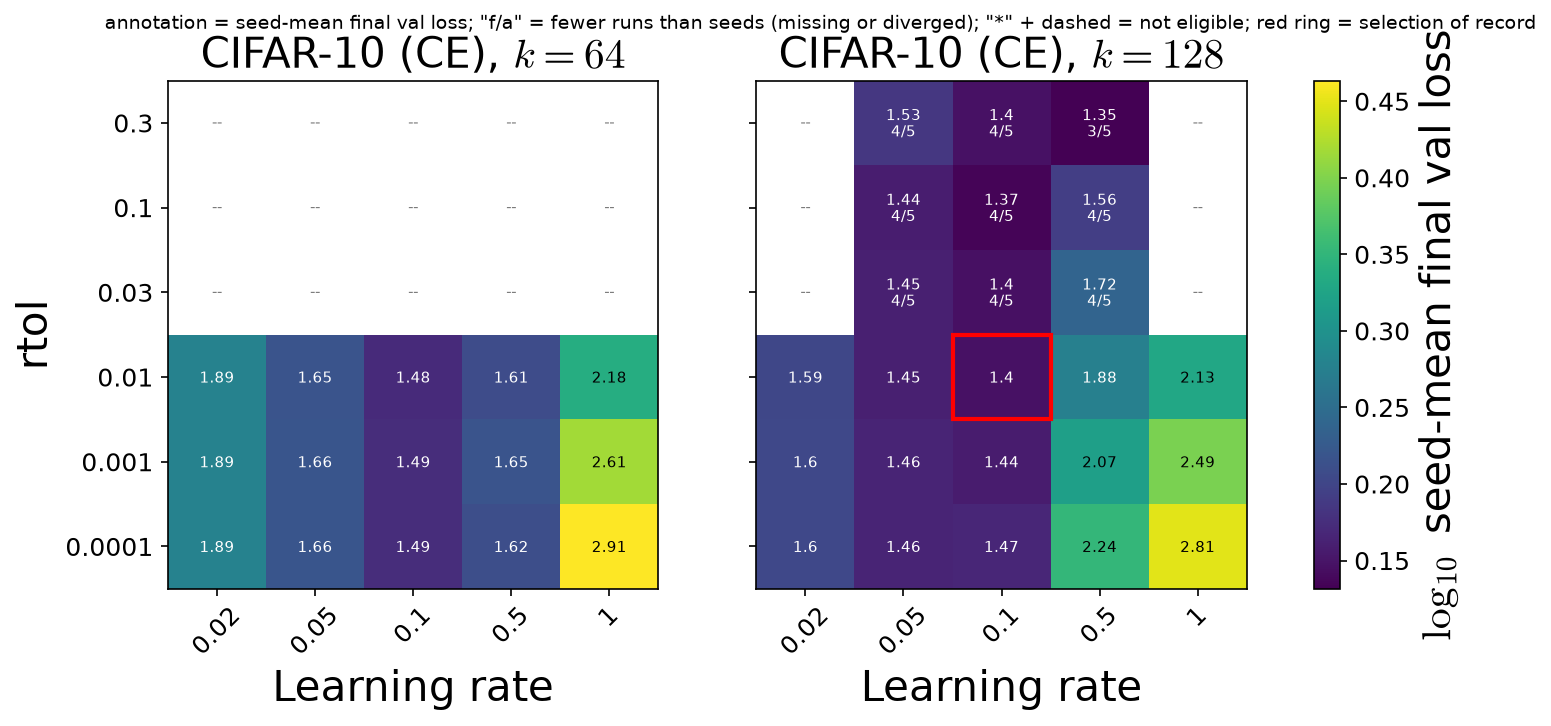

Loaded 775 runs from ../experiment_results/_cache/cifar10_resnet_ce_scan.slim.pkl (slim cache)
cifar10_resnet_ce_scan: 775 runs  |  B=128, 20 epochs, 5 seeds  |  Sven k=[64, 128] rtol=[0.0001, 0.001, 0.01, 0.03, 0.1, 0.3]
  11 diverged run(s), excluded from seed means: {'RMSprop': 8, 'SOAP': 1, 'Muon': 1, 'SGDm': 1}
  manifest: 775 of 635 intended runs present, 10 with no record
    first missing: ['svd_bs128_k128_lr0.05_rtol0.03_svdtorch_mseed4004_lseed4000_gram_bnbatch', 'svd_bs128_k128_lr0.05_rtol0.1_svdtorch_mseed4004_lseed4000_gram_bnbatch', 'svd_bs128_k128_lr0.05_rtol0.3_svdtorch_mseed4004_lseed4000_gram_bnbatch']


plots_v2/cifar/cifar10_resnet_ce_scan_sven_sensitivity.pdf


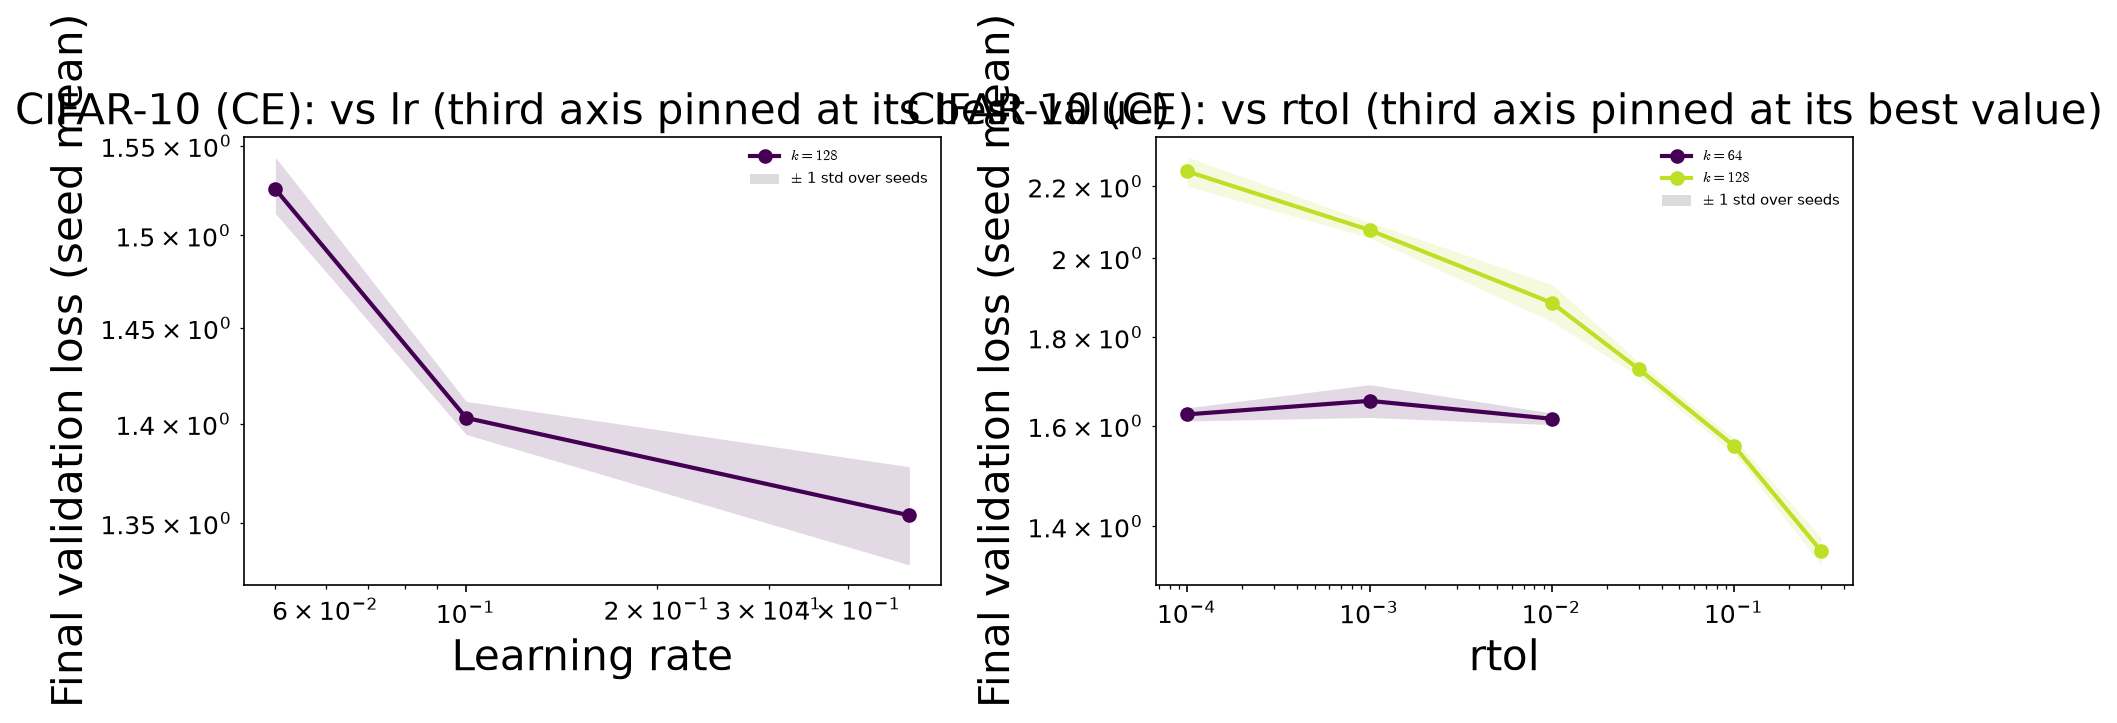

In [10]:
for scan, title in SCANS.items():
    g = GRID[scan]
    ks = sorted(g['k'].dropna().unique())
    # ONE colour scale and ONE pair of axes for every panel: pcolormesh autoscales per
    # axes, so panels drawn independently are coloured on different scales and the single
    # colour bar beside them would describe only the last one
    xs, ys = lf.landscape_axes(g, 'lr', 'rtol')
    vmin, vmax = lf.landscape_scale(g, 'val')
    fig, axes = plt.subplots(1, len(ks), figsize=(5.8 * len(ks), 4.4), squeeze=False,
                             sharey=True)
    n_part = n_inelig = 0
    for ax, k in zip(axes[0], ks):
        im, mat, inelig, partial = lf.plot_sven_landscape(ax, g[g.k == k], x='lr', y='rtol',
                                                          xs=xs, ys=ys, vmin=vmin, vmax=vmax)
        n_part += int(partial.sum()); n_inelig += int(inelig.sum())
        ax.set_title(f'{title}, $k={int(k)}$')
    for ax in axes[0][1:]:
        ax.set_ylabel('')
    fig.suptitle('annotation = seed-mean final val loss; "f/a" = fewer runs than seeds '
                 '(missing or diverged); "*" + dashed = not eligible; '
                 'red ring = selection of record', fontsize=9)
    fig.colorbar(im, ax=axes[0], label='$\\log_{10}$ seed-mean final val loss')
    print(f'{title}: {n_part} cell(s) with fewer runs than seeds, annotated with '
          f'their finished/attempted; {n_inelig} not eligible')
    print(lf.savefig(fig, f'{scan}_sven_landscape', PLOT_DIR)[0])
    plt.show()

    scan_obj = lf.load_scan_obj(scan, plot_dir=PLOT_DIR)
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
    for ax, (x, lines) in zip(axes, (('lr', 'k'), ('rtol', 'k'))):
        pinned = sa.plot_sensitivity(scan_obj, ax, x=x, lines=lines, third='best')
        ax.set_title(f'{title}: vs {x} (third axis pinned at its best value)')
        ax.legend(fontsize=7)
    fig.tight_layout()
    print(lf.savefig(fig, f'{scan}_sven_sensitivity', PLOT_DIR)[0])
    plt.show()


### Does the `k` truncation bind? (the `_diag` pass)

`svd_summary.num_nonzero_svs_epoch` is the number of singular values that survived the
`rtol` cut, averaged over an epoch. If it sits at `k`, then `k` — not `rtol` — is the
binding constraint, i.e. the grid's `rtol` axis buys less than its `k` axis does.

Whether that makes every Sven grid point a *distinct* trajectory is a separate question,
and section 5 answers it two ways rather than asserting it: `headline.budget_table`'s
`distinct_frac` (which counts distinct finals within each `(seed, lr)` group and scales by
the number of learning rates, so a **ragged** grid dilutes it) and
`large_figs.distinct_trajectory_check` (which compares the whole recorded `losses.val` of
every configuration of every seed, bit for bit).


Loaded 55 runs from ../experiment_results/_cache/cifar10_resnet_scan_labelRegression_diag.slim.pkl (slim cache)
CIFAR-10 (label reg.): mean rank used 112.48 of k=128 (87.9%); spectrum sigma_max 1.58e+03, smallest kept 5.99 (5 diag run(s))
Loaded 55 runs from ../experiment_results/_cache/cifar10_resnet_ce_scan_diag.slim.pkl (slim cache)
CIFAR-10 (CE): mean rank used 123.26 of k=128 (96.3%); spectrum sigma_max 456, smallest kept 8.61 (5 diag run(s))


plots_v2/cifar/sven_rank_used.pdf


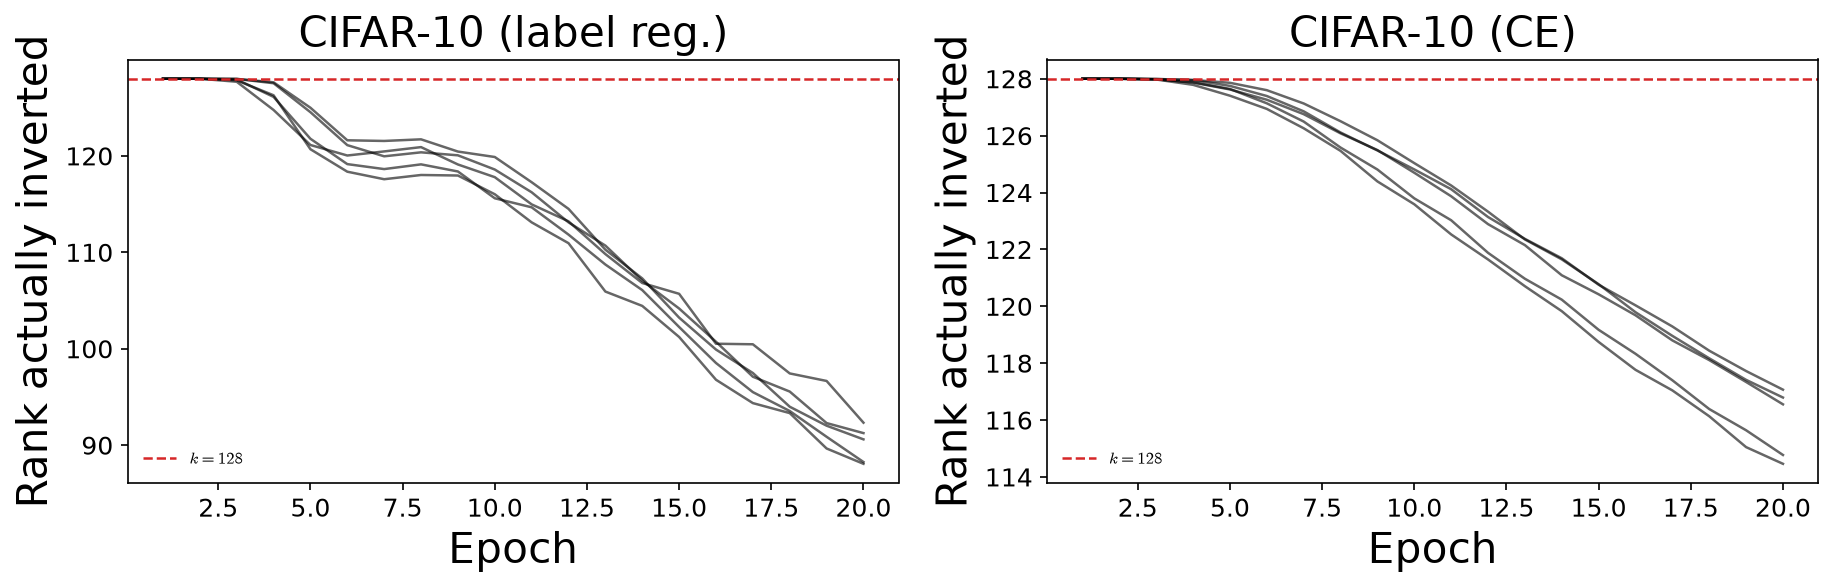

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
for ax, (scan, title) in zip(axes, SCANS.items()):
    ru = lf.sven_rank_used(scan)
    if not len(ru):
        ax.set_visible(False); continue
    for rid, sub in ru.groupby('run_id'):
        ax.plot(sub['epoch'], sub['rank_used'], color=method_color('Sven'), alpha=0.6, lw=1.2)
    k = float(ru['k'].dropna().iloc[0])
    ax.axhline(k, color='C3', ls='--', lw=1.2, label=f'$k={int(k)}$')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Rank actually inverted')
    ax.set_title(title); ax.legend(fontsize=8)
    frac = float(ru['rank_used'].mean() / k)
    print(f'{title}: mean rank used {ru["rank_used"].mean():.2f} of k={int(k)} '
          f'({frac:.1%}); spectrum sigma_max {ru["sv_max"].mean():.3g}, '
          f'smallest kept {ru["sv_min_all"].mean():.3g} '
          f'({len(ru.run_id.unique())} diag run(s))')
fig.tight_layout()
print(lf.savefig(fig, 'sven_rank_used', PLOT_DIR)[0])
plt.show()

## 5. What it cost

Seconds per epoch, time per step and peak GPU memory come from `{scan}_timing` — the
standalone pass, one selected configuration at a time with logging off. The scan's own
wall clock is not comparable (it shared its GPU), and `headline.efficiency_table` carries
the modal GPU of each pass so that is visible rather than assumed.

The tuning-budget table beside it answers the other half of the cost objection: how many
*distinct trajectories* each method's grid actually contains.


### CIFAR-10 (label reg.) — cost of the selected configuration (standalone)
| method | config | s/epoch | x fastest | ms/step | peak mem (MB) | x leanest | total wall (s) | fin/att | GPU |
|---|---|---|---|---|---|---|---|---|---|
| SGD | lr=0.001 | 2.747 ± 0.008307 | 1.00x | 5.805 | 402.88 ± 0 | 1.00x | 54.95 | 5/5 | NVIDIA A100-SXM4-80GB |
| SGD + momentum | lr=0.001 | 2.789 ± 0.01655 | 1.02x | 5.92 | 447.61 ± 0 | 1.11x | 55.79 | 5/5 | NVIDIA A100-SXM4-80GB |
| RMSprop | lr=0.001 | 2.888 ± 0.01731 | 1.05x | 6.201 | 447.61 ± 0 | 1.11x | 57.771 | 5/5 | NVIDIA A100-SXM4-80GB |
| AdamW | lr=0.01, weight_decay=0.01 | 2.977 ± 0.01447 | 1.08x | 6.48 | 492.34 ± 0 | 1.22x | 59.542 | 5/5 | NVIDIA A100-SXM4-80GB |
| Adam | lr=0.01 | 2.985 ± 0.01128 | 1.09x | 6.502 | 492.34 ± 0 | 1.22x | 59.701 | 5/5 | NVIDIA A100-SXM4-80GB |
| Polyak SGD | f_star=0, max_lr=1, eps=1e-08 | 3.45 ± 0.01789 | 1.26x | 7.778 | 402.88 ± 0 | 1.00x | 69.012 | 5/5 | NVIDIA A100-SXM4-80GB |
| Muon | lr=0.01 | 5.56 ± 0.035


### CIFAR-10 (label reg.) — tuning budget: distinct trajectories per method
| label | grid_points | distinct | distinct_frac | n_diverged |
|---|---|---|---|---|
| Stochastic L-BFGS | 45 | 45 | 1 | 0 |
| Sven | 18 | 18 | 1 | 5 |
| AdamW | 7 | 7 | 1 | 0 |
| MuonW | 7 | 7 | 1 | 0 |
| Adam | 7 | 7 | 1 | 0 |
| Muon | 7 | 7 | 1 | 0 |
| RMSprop | 7 | 7 | 1 | 0 |
| SGD + momentum | 7 | 7 | 1 | 15 |
| SGD | 7 | 7 | 1 | 13 |
| SOAP | 7 | 7 | 1 | 0 |
| Polyak SGD | 1 | 1 | 1 | 0 |
Loaded 600 runs from ../experiment_results/_cache/cifar10_resnet_scan_labelRegression.slim.pkl (slim cache)
  Sven distinct_frac 1 over 18 grid points; direct check: 0 pair(s) of configurations share a losses.val curve among 90 runs (18 configurations x 5 seeds).
  -> every Sven grid point is a distinct trajectory on this scan, by both readings.



### CIFAR-10 (CE) — cost of the selected configuration (standalone)
| method | config | s/epoch | x fastest | ms/step | peak mem (MB) | x leanest | total wall (s) | fin/att | GPU |
|---|---|---|---|---|---|---|---|---|---|
| SGD | lr=3 | 2.703 ± 0.01007 | 1.00x | 5.674 | 402.88 ± 0 | 1.00x | 54.076 | 5/5 | NVIDIA A100-SXM4-80GB |
| SGD + momentum | lr=0.3 | 2.778 ± 0.004639 | 1.03x | 5.883 | 447.61 ± 0 | 1.11x | 55.572 | 5/5 | NVIDIA A100-SXM4-80GB |
| RMSprop | lr=0.001 | 2.828 ± 0.01209 | 1.05x | 6.062 | 447.61 ± 0 | 1.11x | 56.562 | 5/5 | NVIDIA A100-SXM4-80GB |
| Adam | lr=0.001 | 2.955 ± 0.01819 | 1.09x | 6.389 | 492.34 ± 0 | 1.22x | 59.098 | 5/5 | NVIDIA A100-SXM4-80GB |
| AdamW | lr=0.01, weight_decay=0.01 | 2.969 ± 0.01125 | 1.10x | 6.442 | 492.34 ± 0 | 1.22x | 59.381 | 5/5 | NVIDIA A100-SXM4-80GB |
| Polyak SGD | f_star=0, max_lr=1, eps=1e-08 | 3.451 ± 0.01523 | 1.28x | 7.757 | 402.88 ± 0 | 1.00x | 69.035 | 5/5 | NVIDIA A100-SXM4-80GB |
| MuonW | lr=0.01, weight_decay=0.1 | 5


### CIFAR-10 (CE) — tuning budget: distinct trajectories per method
| label | grid_points | distinct | distinct_frac | n_diverged |
|---|---|---|---|---|
| Stochastic L-BFGS | 45 | 45 | 1 | 0 |
| Sven | 39 | 37 | 0.9487 | 0 |
| AdamW | 9 | 9 | 1 | 0 |
| MuonW | 9 | 9 | 1 | 0 |
| Adam | 9 | 9 | 1 | 0 |
| Muon | 9 | 9 | 1 | 1 |
| RMSprop | 9 | 9 | 1 | 8 |
| SGD + momentum | 9 | 9 | 1 | 1 |
| SGD | 9 | 9 | 1 | 0 |
| SOAP | 9 | 9 | 1 | 1 |
| Polyak SGD | 1 | 1 | 1 | 0 |
Loaded 775 runs from ../experiment_results/_cache/cifar10_resnet_ce_scan.slim.pkl (slim cache)
  Sven distinct_frac 0.9487 over 39 grid points; direct check: 0 pair(s) of configurations share a losses.val curve among 185 runs (39 configurations x 5 seeds).
  -> distinct_frac < 1 is a RAGGED-GRID artefact: 9 of 39 cells have fewer runs than seeds while the rtol extension lands, so the (seed, lr) groups trajectory_table averages over are uneven. No two Sven trajectories coincide, and the number returns toward 1.00 when the e

plots_v2/cifar/cifar10_resnet_scan_labelRegression_cost.pdf


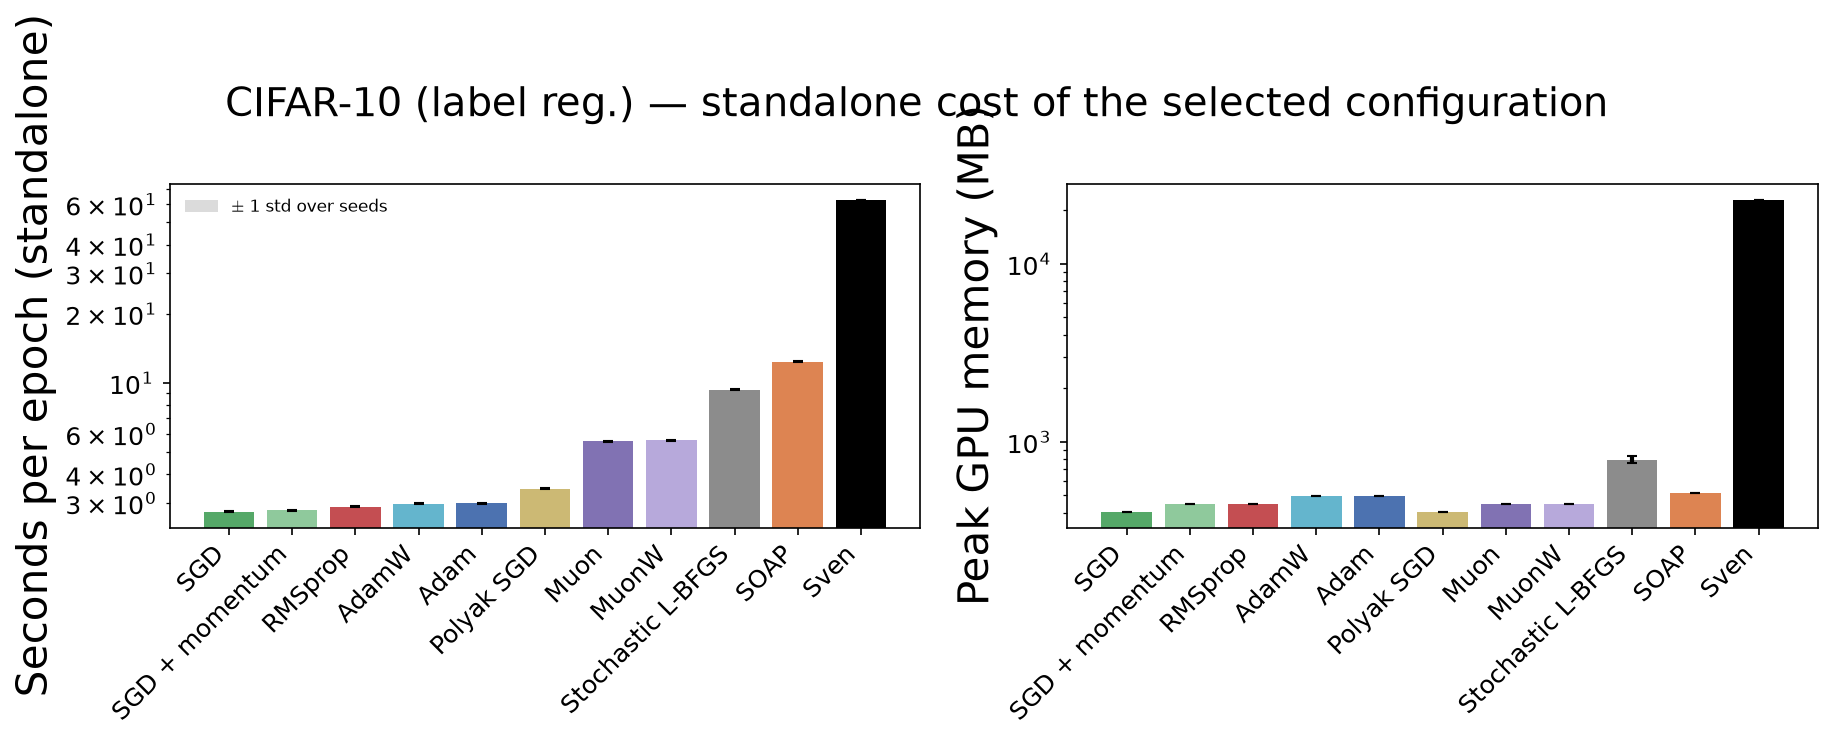

plots_v2/cifar/cifar10_resnet_ce_scan_cost.pdf


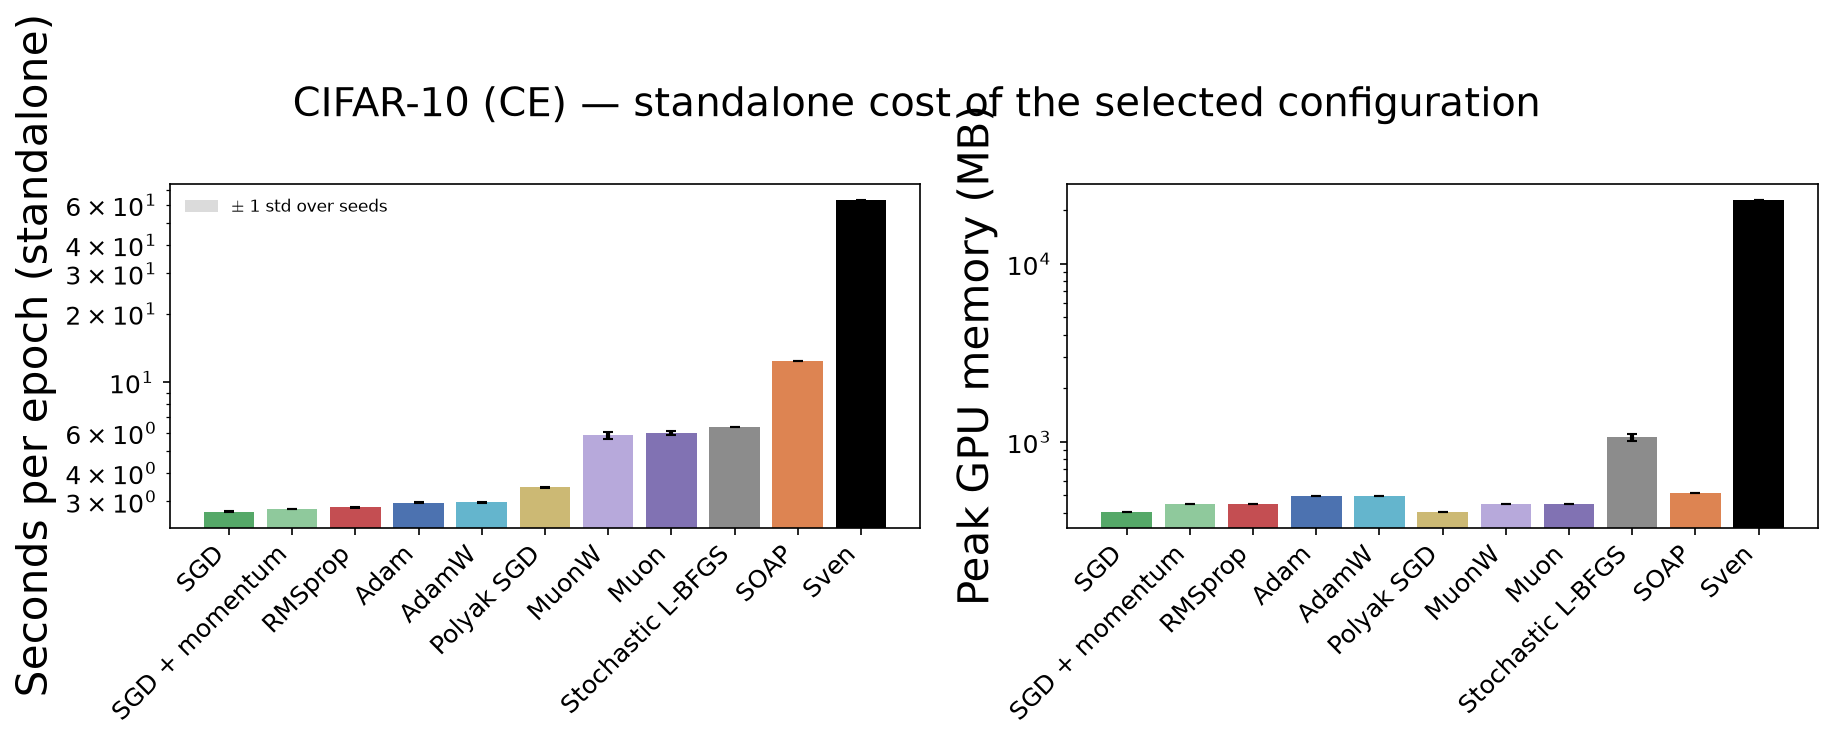

In [12]:
EFF = {}
for scan, title in SCANS.items():
    EFF[scan] = hl.efficiency_table(scan)
    show(lf.cost_view(EFF[scan]), f'{title} — cost of the selected configuration (standalone)')
    print('  times from:', EFF[scan].attrs['times_from'], '|', EFF[scan].attrs['inflation_means'])
    b = hl.budget_table(scan)
    show(b[['label', 'grid_points', 'distinct', 'distinct_frac', 'n_diverged']],
         f'{title} — tuning budget: distinct trajectories per method')
    # Two readings of "distinct", because on a ragged grid they differ. `distinct_frac`
    # below 1 here is an artefact of trajectory_table's (seed, lr) grouping while the
    # extension covers 3 of 5 seeds and 3 of 5 learning rates; the direct check says
    # whether any two configurations really produced the same run.
    sven = b[b['label'] == 'Sven']
    frac = float(sven['distinct_frac'].iloc[0]) if len(sven) else float('nan')
    chk = lf.distinct_trajectory_check(scan)
    g = GRID[scan]
    ragged = int(((g['finished'] < g['attempted'])).sum())
    print(f'  Sven distinct_frac {frac:.4g} over {int(sven["grid_points"].iloc[0])} grid '
          f'points; direct check: {chk["n_collisions"]} pair(s) of configurations share a '
          f'losses.val curve among {chk["n_curves"]} runs '
          f'({chk["n_configs"]} configurations x {chk["n_seeds"]} seeds).')
    if frac < 1 and ragged:
        print(f'  -> distinct_frac < 1 is a RAGGED-GRID artefact: {ragged} of '
              f'{len(g)} cells have fewer runs than seeds while the rtol extension lands, '
              f'so the (seed, lr) groups trajectory_table averages over are uneven. No two '
              f'Sven trajectories coincide, and the number returns toward 1.00 when the '
              f'extension completes.')
    elif frac >= 1:
        print('  -> every Sven grid point is a distinct trajectory on this scan, by both '
              'readings.')

for scan, title in SCANS.items():
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
    lf.plot_cost_bars(axes, EFF[scan])
    fig.suptitle(f'{title} — standalone cost of the selected configuration')
    fig.tight_layout()
    print(lf.savefig(fig, f'{scan}_cost', PLOT_DIR)[0])
    plt.show()


## 6. Fig 5 (R1 Q2): quality and cost against the parameter fraction

`rebuttal_fig5_cifar_paramfrac_scan`: CIFAR-10 / ResNet18, Sven, **3 model seeds** per
parameter fraction. The x axis is the **actual** fraction recorded by the run
(`actual_param_fraction`), not the requested one. The objective is **label regression**,
not the cross-entropy of the table above it — the losses on this figure are not comparable
with the CE numbers in section 1.

**The mask is resampled every step.** `mask_mode: elementwise` draws a fresh Bernoulli mask
per optimizer step, so `f` is the fraction of parameters updated *at a step*, not a fixed
subnetwork; every parameter is eventually updated. A fixed mask would be a different
experiment and would answer a different question.

**One fixed configuration, and it is not the selected one — the confound to state with the
figure** (EXPERIMENTS.md §3.3). All 15 runs share a single `(k, lr, rtol)`: nothing was
re-tuned per fraction. That set point is the *pre-Gram classic* best, still flagged `SET
POINT, STILL TENTATIVE` in its config, and it was **not** re-derived from the
BatchNorm-fixed headline scan, whose Sven optimum is a different `k` and a different `lr`
(the cell below prints both and compares them). It matters here because the scan's single
learning rate is the top of the headline grid — the cell where *all* of that scan's Sven
divergences sit — and both of Fig 5's blow-ups are at it. So the low-`f` collapse bounds
**this configuration at this learning rate**; it is not by itself a measurement of masking
at fraction `f`. The framing cell says so in the same words it computes the numbers with.


In [13]:
PF = lf.paramfrac_table()
show(lf.paramfrac_view(PF), 'Fig 5 — parameter fraction: quality and cost (3 seeds)')
print('\n' + PF.attrs['mask_note'])
pf_df = add_derived(load_results(FIG5))

# The ONE configuration this scan ran, computed -- including the objective, which the
# figure has to carry because this notebook reports two of them.
PFCFG = lf.paramfrac_config(pf_df)
assert not PFCFG['varies'], f'Fig 5 is no longer one configuration: {PFCFG["varies"]}'
print(f"\nscan: {PFCFG['n_runs']} runs, {PFCFG['n_seeds']} model seeds "
      f"{PFCFG['seeds']}, {PFCFG['num_epochs']} epochs, B={PFCFG['batch_size']}, "
      f"capture={PFCFG['gram_capture']}, bn_mode={PFCFG['bn_mode']}")
print(f"objective : {PFCFG['loss']}  ({PFCFG['loss_label']})  <- NOT the cross-entropy of "
      f"section 1; the losses are on different scales")
print(f"Sven      : {PFCFG['label']}, kappa={PFCFG['kappa']:g} -- the SAME configuration at "
      f"every one of the {len(PFCFG['fractions'])} fractions "
      f"{[f'{f:g}' for f in PFCFG['fractions']]}: {PFCFG['fixed_config_note']}")

# ... and how it compares with the selection of record on the matching headline scan.
HEADLINE_SCAN = 'cifar10_resnet_scan_labelRegression'
HSVEN = lf.headline_sven_config(HEADLINE_SCAN)
diff = [f"{k}: Fig 5 {PFCFG[k]:g} vs selected {HSVEN[k]:g}"
        for k in ('k', 'lr', 'rtol')
        if HSVEN.get(k) is not None and float(PFCFG[k]) != float(HSVEN[k])]
print(f"\nheadline {SCANS[HEADLINE_SCAN]} selection of record: Sven {HSVEN['label']}")
print('  differs from Fig 5 in: ' + ('; '.join(diff) if diff else 'nothing')
      + ('  -> Fig 5 is NOT the headline-selected configuration (EXPERIMENTS.md 3.3: the '
         'pre-Gram "SET POINT, STILL TENTATIVE", not re-derived from the BN-fixed scan '
         'before launch)' if diff else ''))

# Where the divergences sit, here and on the headline grid it was taken from.
n_bad, n_all, bad_cells = lf.divergence_lrs(FIG5)
h_bad, h_all, h_cells = lf.divergence_lrs(HEADLINE_SCAN)
print(f"\ndivergences (the wide rule: status, non-finite, or final val > 10x val[0]): "
      f"{n_bad} of {n_all} here")
if len(bad_cells):
    print(f"  all at the scan's only lr={PFCFG['lr']:g}: "
          + ', '.join(f"lr={r['lr']:g} k={r['k']:g} rtol={r['rtol']:g} ({int(r['n'])})"
                      for _, r in bad_cells.iterrows()))
same_lr = int(h_cells.loc[h_cells['lr'] == PFCFG['lr'], 'n'].sum()) if len(h_cells) else 0
print(f"  on the headline {SCANS[HEADLINE_SCAN]} Sven grid: {h_bad} of {h_all} diverged, "
      f"{same_lr} of them at that same lr={PFCFG['lr']:g} "
      f"-> this learning rate is the divergence-prone cell of the grid, not a neutral choice")
bad = pf_df[pf_df['diverged']][['param_fraction', 'model_seed', 'status']].copy()
if len(bad):
    # `status` is 'ok': these are caught by the WIDE rule (final val > 10x val[0]), which
    # is the definition selection and every table here use -- not by the runner's status
    bad['val[0]'] = [pf_df.loc[i, 'losses']['val'][0] for i in bad.index]
    bad['val[-1]'] = [pf_df.loc[i, 'losses']['val'][-1] for i in bad.index]
    bad['ratio'] = bad['val[-1]'] / bad['val[0]']
    show(bad.reset_index(drop=True), 'the diverged runs (wide rule: final val > 10x val[0])')


Loaded 15 runs from ../experiment_results/_cache/rebuttal_fig5_cifar_paramfrac_scan.slim.pkl (slim cache)

### Fig 5 — parameter fraction: quality and cost (3 seeds)
| f (requested) | f (actual) | mask | val | test | val acc | test acc | peak mem (MB) | ms/step | finished/attempted | diverged | mem x full | ms/step x full |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 0.05 | 0.05 | elementwise | 9.018 ± 2.478 | 8.963 ± 1.516 | 0.101 ± 0.00764 | 0.1 ± 0.00382 | 11816 ± 0 | 342.1 ± 2.139 | 2/3 | 1 | 0.51x | 1.92x |
| 0.1 | 0.1 | elementwise | 6.334 ± 0.03756 | 6.479 ± 0.493 | 0.181 ± 0.00962 | 0.178 ± 0.0117 | 12107 ± 0 | 349 ± 1.966 | 2/3 | 1 | 0.53x | 1.96x |
| 0.25 | 0.25 | elementwise | 4.36 ± 1.049 | 4.224 ± 1.584 | 0.152 ± 0.0281 | 0.149 ± 0.0293 | 12979 ± 0 | 364.8 ± 3.002 | 3/3 | 0 | 0.57x | 2.05x |
| 0.5 | 0.5 | elementwise | 0.7667 ± 0.05588 | 0.9753 ± 0.203 | 0.731 ± 0.00329 | 0.729 ± 0.00215 | 14433 ± 0 | 389.1 ± 0.9423 | 3/3 | 0 | 0.63x | 2.18x |
| 1 | 1 | none | 


divergences (the wide rule: status, non-finite, or final val > 10x val[0]): 2 of 15 here
  all at the scan's only lr=1: lr=1 k=64 rtol=0.001 (2)
  on the headline CIFAR-10 (label reg.) Sven grid: 5 of 90 diverged, 5 of them at that same lr=1 -> this learning rate is the divergence-prone cell of the grid, not a neutral choice

### the diverged runs (wide rule: final val > 10x val[0])
| param_fraction | model_seed | status | val[0] | val[-1] | ratio |
|---|---|---|---|---|---|
| 0.1 | 4000 | ok | 1.339 | 19.82 | 14.81 |
| 0.05 | 4002 | ok | 2.031 | 244.5 | 120.4 |


plots_v2/cifar/fig5_paramfrac_quality.pdf


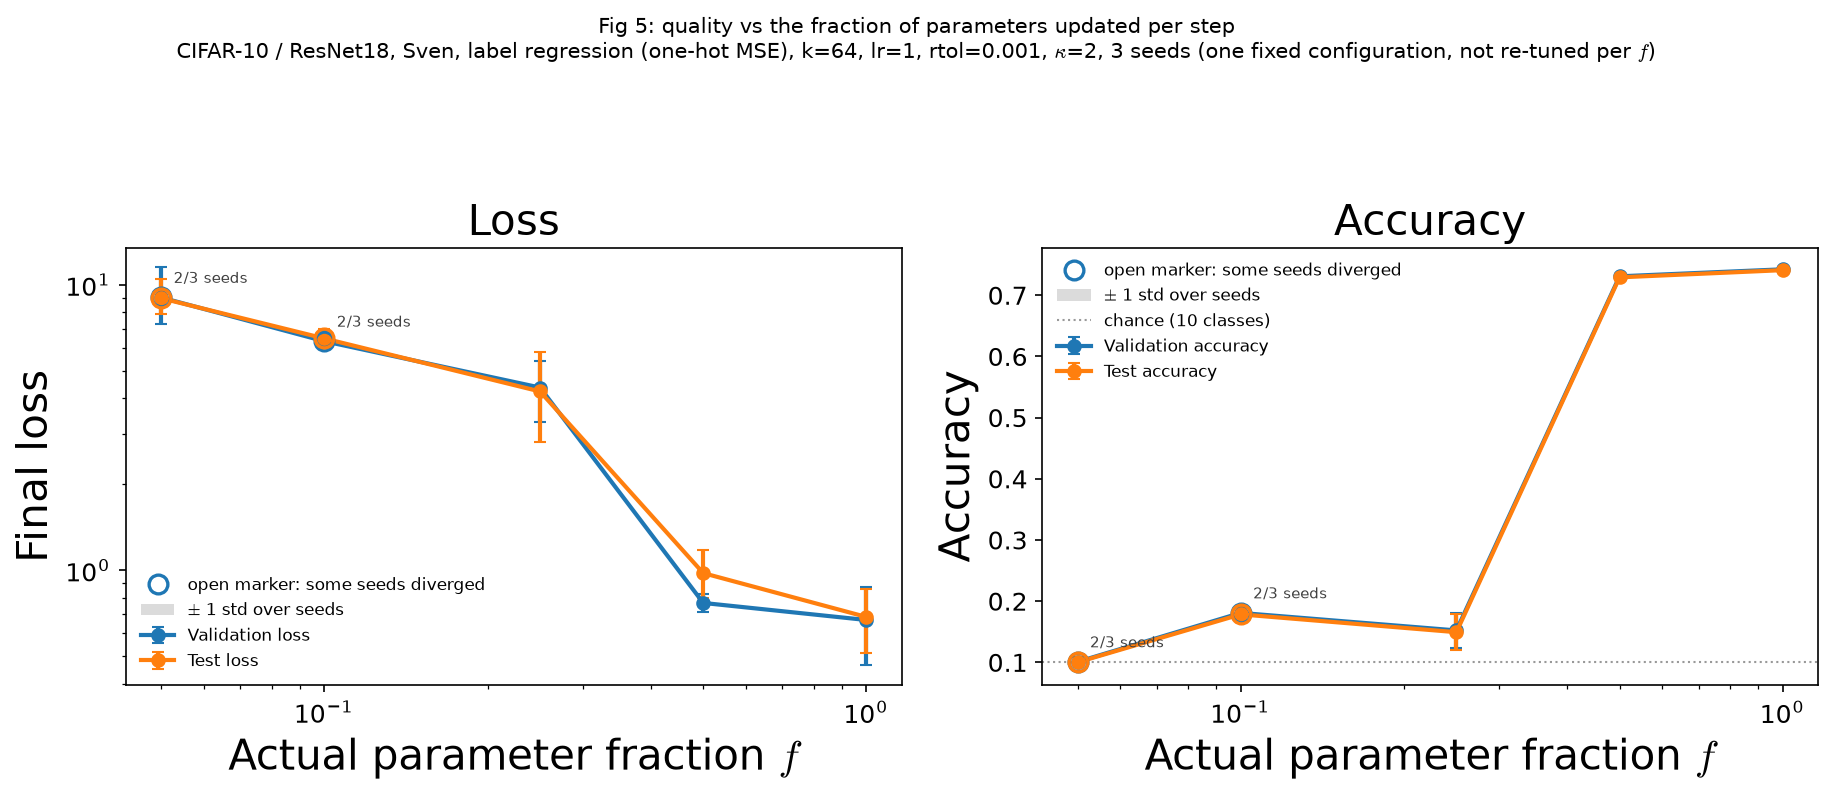


### runs behind each point
| actual | finished | attempted | n_diverged |
|---|---|---|---|
| 0.05 | 2 | 3 | 1 |
| 0.1 | 2 | 3 | 1 |
| 0.25 | 3 | 3 | 0 |
| 0.5 | 3 | 3 | 0 |
| 1 | 3 | 3 | 0 |


,actual,finished,attempted,n_diverged
0,0.05,2,3,1
1,0.10,2,3,1
2,0.25,3,3,0
3,0.50,3,3,0
4,1.00,3,3,0


In [14]:
FIG5_SUB = (f"CIFAR-10 / ResNet18, Sven, {PFCFG['loss_label']}, {PFCFG['label']}, "
            f"$\\kappa$={PFCFG['kappa']:g}, {PFCFG['n_seeds']} seeds "
            f"(one fixed configuration, not re-tuned per $f$)")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.9))
counts = lf.plot_paramfrac_quality(axes, PF)
axes[0].set_title('Loss'); axes[1].set_title('Accuracy')
axes[1].axhline(0.1, color='0.6', lw=1, ls=':', label='chance (10 classes)')
axes[1].legend(fontsize=8)
fig.suptitle('Fig 5: quality vs the fraction of parameters updated per step\n'
             + FIG5_SUB, y=1.09, fontsize=10)
fig.tight_layout()
print(lf.savefig(fig, 'fig5_paramfrac_quality', PLOT_DIR)[0])
plt.show()
show(counts, 'runs behind each point')


profile results: /n/home11/sambt/iaifi/sv3/profile_results_v2  (v2)


profile overlay: 5 configuration(s) from profile_results_v2 (v2 -- step times NOT comparable, drawn on the memory panel only)


plots_v2/cifar/fig5_paramfrac_cost.pdf


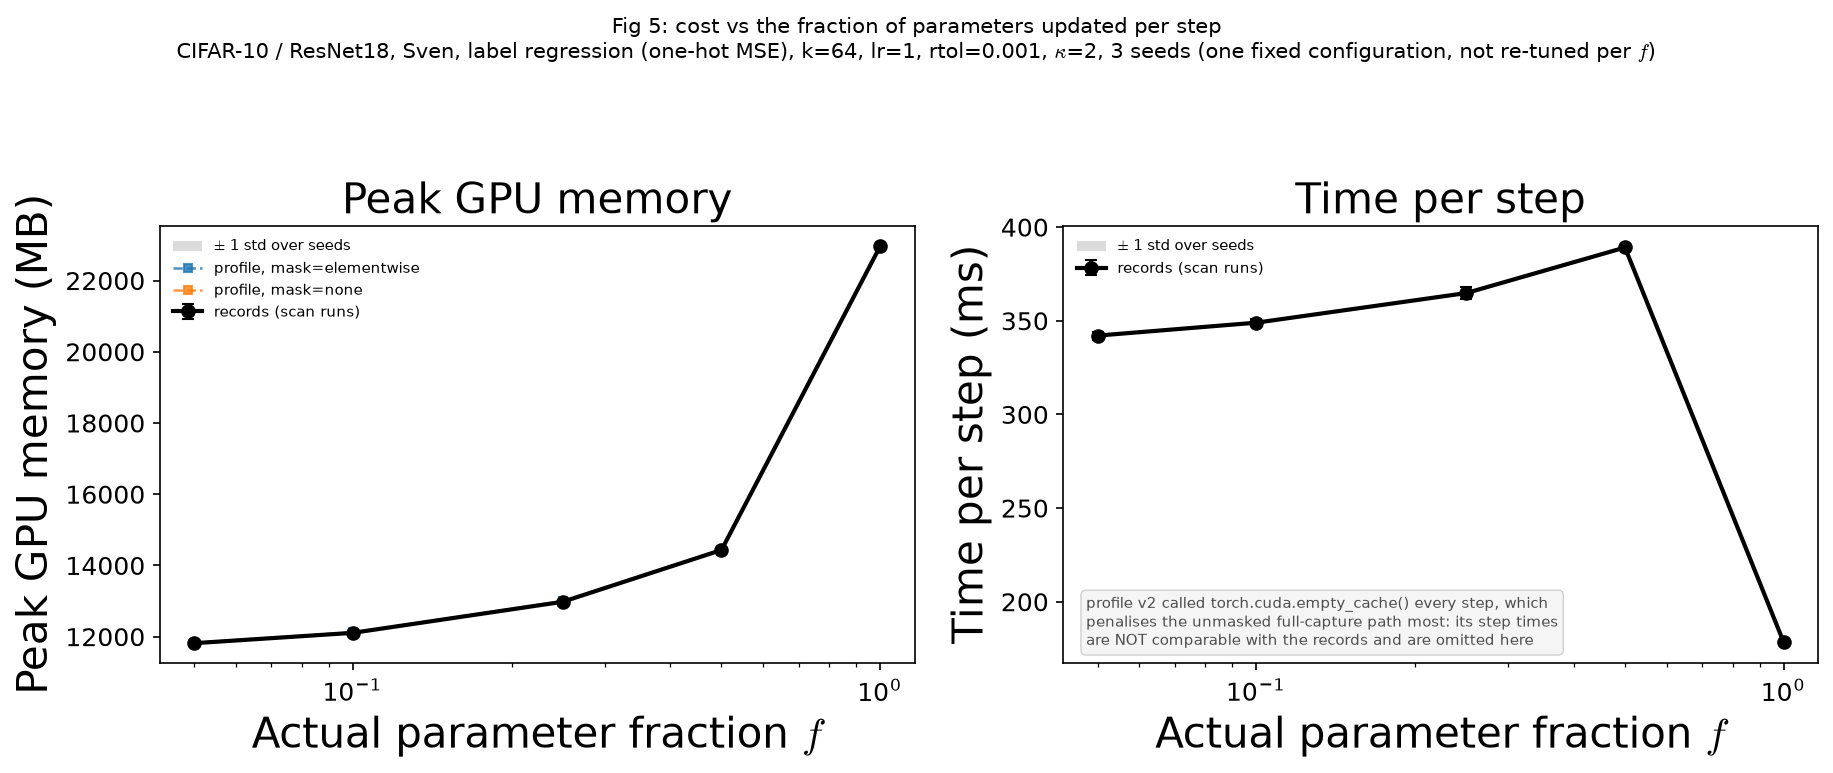


Honest cost note — full-Jacobian capture does not get cheaper with an element mask.
  f=1 (no mask):  178.3 ms/step, 22965 MB peak
  slowest masked: f=0.5 at 389.1 ms/step (x2.18), 14433 MB (x0.63)
  smallest f=0.05: memory only falls to x0.51 of the unmasked run while the step is x1.92 — the capture still walks the whole parameter vector, the mask only zeroes the update.
  profile (profile_results_v2) for comparison: masked 530–626 ms/step against 846 ms unmasked — the OPPOSITE direction to the records, because the v2 pass called torch.cuda.empty_cache() every step and that penalises the unmasked full-capture path most. Only v3 is comparable, so the step-time panel shows the records alone.
  memory agrees to 0.06% at f=1, which is why that overlay is drawn.


In [15]:
prof = None
prof_is_v3 = False
root = None
try:
    import profile_helpers as ph
    root = Path(ph.results_root(verbose=False))
    prof_is_v3 = root.resolve() == Path(ph.ROOT_V3).resolve()
    p = ph.load_profiles()
    # Only the mask granularities the scan itself ran ('elementwise', and 'none' at
    # f = 1): the profile's 'rows' / 'tensor' arms are a different experiment and would
    # add legend entries with nothing of the records to compare against.
    prof = p[(p.arch == 'cifar_resnet18') & (p.study == 'param_fraction')
             & (p.method == 'gram_full') & p.status.isin(ph.TIMED)
             & p.mask_mode.isin(set(PF['mask_mode']) | {'none'})]
    verdict = ('v3 -- measured with empty_cache off, comparable with the records'
               if prof_is_v3 else
               'v2 -- step times NOT comparable, drawn on the memory panel only')
    print(f'profile overlay: {len(prof)} configuration(s) from {root.name} ({verdict})')
except Exception as exc:                      # a profile root that is not there yet
    print('no profile overlay:', type(exc).__name__, exc)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.9))
# The step-time overlay is gated on v3: v2 called torch.cuda.empty_cache() every step,
# which costs the UNMASKED full-capture path most, so on that panel v2 and the records
# disagree about the SIGN of the masking cost. Drawn together, the figure alone would
# reverse Fig 5's conclusion for anyone who does not read this cell.
lf.plot_paramfrac_cost(axes, PF, profiles=prof, profile_step_times=prof_is_v3)
axes[0].set_title('Peak GPU memory'); axes[1].set_title('Time per step')
fig.suptitle(f'Fig 5: cost vs the fraction of parameters updated per step\n{FIG5_SUB}',
             y=1.06, fontsize=10)
fig.tight_layout()
print(lf.savefig(fig, 'fig5_paramfrac_cost', PLOT_DIR)[0])
plt.show()

full = PF[np.isclose(PF['actual'], 1.0)].iloc[0]
worst = PF.iloc[PF['ms_per_step'].idxmax()]
print(f"\nHonest cost note — full-Jacobian capture does not get cheaper with an element mask.")
print(f"  f=1 (no mask):  {full['ms_per_step']:.1f} ms/step, {full['peak_mem_mb']:.0f} MB peak")
print(f"  slowest masked: f={worst['actual']:g} at {worst['ms_per_step']:.1f} ms/step "
      f"(x{worst['ms_per_step'] / full['ms_per_step']:.2f}), {worst['peak_mem_mb']:.0f} MB "
      f"(x{worst['peak_mem_mb'] / full['peak_mem_mb']:.2f})")
lowest = PF.iloc[0]
print(f"  smallest f={lowest['actual']:g}: memory only falls to "
      f"x{lowest['peak_mem_mb'] / full['peak_mem_mb']:.2f} of the unmasked run while the "
      f"step is x{lowest['ms_per_step'] / full['ms_per_step']:.2f} — the capture still walks "
      f"the whole parameter vector, the mask only zeroes the update.")
if prof is not None and len(prof):
    pmask = prof[prof['mask_mode'] != 'none'].sort_values('pf')
    pf1 = prof[np.isclose(prof['pf'], 1.0)]
    print(f"  profile ({root.name}) for comparison: masked "
          f"{pmask['step_ms'].min():.0f}–{pmask['step_ms'].max():.0f} ms/step against "
          + (f"{float(pf1['step_ms'].iloc[0]):.0f} ms unmasked" if len(pf1) else 'no f=1 point')
          + (", i.e. the SAME direction as the records" if prof_is_v3 else
             " — the OPPOSITE direction to the records, because the v2 pass called "
             "torch.cuda.empty_cache() every step and that penalises the unmasked "
             "full-capture path most. Only v3 is comparable, so the step-time panel "
             "shows the records alone."))
    if len(pf1):
        print(f"  memory agrees to "
              f"{abs(float(pf1['peak_mb'].iloc[0]) / full['peak_mem_mb'] - 1):.2%} at f=1, "
              f"which is why that overlay is drawn.")


## 7. The framing, computed

Everything below is computed from the tables above — nothing is typed in. Re-executing the
notebook after a re-selection re-writes it.

In [16]:
def framing(scan):
    title = SCANS[scan]
    tbl, eff = CONF[scan], EFF[scan]
    val = pd.to_numeric(tbl['val_conf'], errors='coerce')
    acc = pd.to_numeric(tbl['acc_conf'], errors='coerce')
    n = int(np.isfinite(val).sum())
    sven = tbl[tbl.method == 'Sven'].iloc[0]
    rank_val = int(val.rank(method='min')[tbl.method.eq('Sven')].iloc[0])
    rank_acc = int(acc.rank(method='min', ascending=False)[tbl.method.eq('Sven')].iloc[0])
    others = (tbl.loc[tbl.method.ne('Sven'), ['display', 'acc_conf']]
              .dropna().sort_values('acc_conf'))
    weak = ', '.join(f'{r["display"]} {100 * r["acc_conf"]:.1f}'
                     for _, r in others.head(2).iterrows())
    acc_other = pd.to_numeric(others['acc_conf'], errors='coerce')
    e = eff.set_index('method')
    fastest = e['epoch_s'].idxmin()
    # Robustness over the runs that HAVE A RECORD -- `attempted` is the manifest count and
    # includes runs that never started (EXPERIMENTS.md section 7).
    d = lf.grid_divergence_counts(GRID[scan])
    rob = (f'* Robustness: Sven diverged on {d["diverged"]} of {d["recorded"]} runs of its '
           f'own grid here that have a record ({d["rate"]:.1%})')
    rob += (f'; {d["missing"]} of the {d["attempted"]} intended runs have not started yet '
            f'and are not counted either way.' if d['missing'] else
            f' = all {d["attempted"]} intended runs.')
    lines = [
        f'### {title}',
        f'* Sven is **{rank_val} of {n}** on validation loss and **{rank_acc} of {n}** on '
        f'test accuracy (confirmation seeds, {hl.fmt_counts(sven["fin_conf"], sven["att_conf"])}).',
        f'* Test accuracy: Sven **{100 * sven["acc_conf"]:.1f}%** against '
        f'**{100 * acc_other.min():.1f}–{100 * acc_other.max():.1f}%** for the '
        f'{len(acc_other)} baselines ({weak} are the weak two; the other '
        f'{len(acc_other) - 2} span {100 * acc_other.iloc[2]:.1f}–'
        f'{100 * acc_other.max():.1f}).',
        f'* Cost: **{e.loc["Sven", "epoch_s"]:.1f} s/epoch** against '
        f'{e["epoch_s"].drop("Sven").min():.2f}–{e["epoch_s"].drop("Sven").max():.2f} s '
        f'(fastest: {method_label(fastest)}), and '
        f'{e.loc["Sven", "peak_gpu_mem_mb"]:.0f} MB peak against '
        f'{e["peak_gpu_mem_mb"].drop("Sven").min():.0f}–'
        f'{e["peak_gpu_mem_mb"].drop("Sven").max():.0f} MB.',
        f'* Optimisation vs generalisation: train (eval mode) '
        f'**{sven["treval_conf"]:.4g}** against a method median of '
        f'{np.nanmedian(pd.to_numeric(tbl["treval_conf"], errors="coerce")):.4g}; '
        f'validation {sven["val_conf"]:.4g}.',
        f'* Selection optimism on this scan: {sven["gap_val_rel"]:+.1%} for Sven '
        f'(confirmation vs tuning seeds).',
        rob,
    ]
    return '\n'.join(lines)

for scan in SCANS:
    print(framing(scan), '\n')

print('### Fig 5')
full = PF[np.isclose(PF['actual'], 1.0)].iloc[0]
best_masked = PF[PF['actual'] < 1.0].sort_values('val').iloc[0]
print(f'* What ran: ONE Sven configuration — {PFCFG["label"]}, {PFCFG["loss_label"]}, '
      f'{PFCFG["n_seeds"]} seeds — at every fraction, **not re-tuned per f**, and not the '
      f'configuration the headline {SCANS[HEADLINE_SCAN]} scan selected '
      f'({HSVEN["label"]}). EXPERIMENTS.md §3.3 flags it as the pre-Gram '
      f'"SET POINT, STILL TENTATIVE".')
print(f'* Updating every parameter (f=1) reaches val {full["val"]:.4g} / test accuracy '
      f'{100 * full["test_acc"]:.1f}%; the best masked fraction (f={best_masked["actual"]:g}) '
      f'reaches {best_masked["val"]:.4g} / {100 * best_masked["test_acc"]:.1f}%. '
      f'The f=1 point itself is volatile: its {int(full["attempted"])} seeds span '
      f'{full["val_min"]:.3g}–{full["val_max"]:.3g} (± {full["val_std"]:.3g}).')
collapse = PF[(PF['actual'] < 1.0) & (PF['test_acc'] < 0.25)]
if len(collapse):
    seeds_txt = ', '.join(f'f={r["actual"]:g}: '
                          f'{hl.fmt_counts(r["finished"], r["attempted"])} seeds'
                          for _, r in collapse.iterrows())
    print(f'* At f <= {collapse["actual"].max():g} the runs reach test accuracy '
          f'{100 * collapse["test_acc"].min():.1f}–{100 * collapse["test_acc"].max():.1f}% '
          f'against a 10% chance rate ({seeds_txt}), '
          f'with {int(collapse["n_diverged"].sum())} diverged run(s). '
          f'**What this bounds:** this configuration at lr={PFCFG["lr"]:g} — the scan\'s '
          f'only learning rate, where both blow-ups sit and where {same_lr} of the '
          f'{h_bad} divergences of the headline label-regression Sven grid also sit. '
          f'A fixed, untuned, divergence-prone lr can produce this collapse on its own, so '
          f'it is not by itself a measurement of masking at fraction f.')
print(f'* The mask does not pay for itself: {full["ms_per_step"]:.1f} ms/step unmasked '
      f'against {PF[PF["actual"] < 1.0]["ms_per_step"].min():.1f}–'
      f'{PF[PF["actual"] < 1.0]["ms_per_step"].max():.1f} ms masked, while peak memory only '
      f'falls to x{PF["peak_mem_mb"].min() / full["peak_mem_mb"]:.2f}. '
      f'This is the one Fig-5 conclusion the confound above does not touch: it is a cost '
      f'measurement of the same code path at every f.')
if PROVISIONAL:
    print('\n[PROVISIONAL] ' + ', '.join(SCANS.get(s, s) for s in PROVISIONAL)
          + ' — re-run tools/select_best.py and this notebook when the extension lands.')


### CIFAR-10 (label reg.)
* Sven is **9 of 11** on validation loss and **9 of 11** on test accuracy (confirmation seeds, 5/5).
* Test accuracy: Sven **69.4%** against **45.6–77.9%** for the 10 baselines (SGD 45.6, SGD + momentum 54.5 are the weak two; the other 8 span 69.6–77.9).
* Cost: **62.9 s/epoch** against 2.75–12.37 s (fastest: SGD), and 22965 MB peak against 403–794 MB.
* Optimisation vs generalisation: train (eval mode) **0.06737** against a method median of 0.1189; validation 0.4838.
* Selection optimism on this scan: +0.7% for Sven (confirmation vs tuning seeds).
* Robustness: Sven diverged on 5 of 90 runs of its own grid here that have a record (5.6%) = all 90 intended runs. 

### CIFAR-10 (CE)
* Sven is **9 of 11** on validation loss and **11 of 11** on test accuracy (confirmation seeds, 5/5).
* Test accuracy: Sven **53.0%** against **56.8–77.9%** for the 10 baselines (SGD + momentum 56.8, Polyak SGD 63.2 are the weak two; the other 8 span 68.6–77.9).
* Cost: **63.0 s/epoc